In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

In [2]:
csv_path = Path(
    r"C:\Users\deqin\osm_temporal_outputs\osm_temporal_change_register_2021_latest.csv"
)

gpkg_path = Path(
    r"C:\Users\deqin\osm_temporal_outputs\osm_temporal_change_register_2021_latest.gpkg"
)

print("CSV exists:", csv_path.exists())
print("GPKG exists:", gpkg_path.exists())

CSV exists: True
GPKG exists: True


In [3]:
osm_register_gdf = gpd.read_file(
    gpkg_path,
    layer="osm_temporal_register"
)

print("GeoPackage shape:", osm_register_gdf.shape)
print("CRS:", osm_register_gdf.crs)

osm_register_gdf.head()

GeoPackage shape: (632361, 12)
CRS: EPSG:25833


,osm_id_old,old_area_m2,n_latest_matches,total_intersection_area_m2,max_overlap_old,max_overlap_new,total_overlap_old,coverage_old,match_status,temporal_class,candidate_group,geometry
0,200902863,79.804382,1,79.804382,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building,"MULTIPOLYGON (((392071.791 5810757.515, 392082..."
1,200902893,118.886808,1,118.886808,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building,"MULTIPOLYGON (((392030.27 5810755.501, 392045...."
2,271261713,30.412556,1,30.412556,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building,"MULTIPOLYGON (((392035.449 5810884.387, 392034..."
3,200902913,93.287418,1,93.287418,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building,"MULTIPOLYGON (((392005.194 5810576.345, 392012..."
4,271351155,24.428677,1,24.428677,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building,"MULTIPOLYGON (((392028.129 5810656.236, 392025..."


In [16]:
df=pd.read_csv(r'C:\Users\deqin\osm_temporal_outputs\MATCAD_Energy_Age_Denkmal_PopPressure_Abriss_attributes.csv')

In [17]:
print(type(df))
print(df.shape)
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
(327296, 23)
['building_serial_id', 'bldg_gmlid', 'bldg_area', 'bldg_volume', 'BtySig', 'energy_intensity_kwh_m3a', 'denkmal_status', 'pop_density_pressure_change', 'pop_density_pressure_pct_change', 'reporting_of_demolition', 'number_of_age_periods', 'dominant_age_share', 'dominant_age_period_label', 'dominant_age_midpoint', 'weighted_average_construction_year', 'weighted_average_age_2015', 'dominant_age_2015', 'earliest_age_midpoint', 'latest_age_midpoint', 'age_distribution_range', 'demolition_target', 'age_data_available', 'density_change_available']


In [18]:
print("Total records:", len(df))
print("Unique bldg_gmlid:", df["bldg_gmlid"].nunique())
print("Missing bldg_gmlid:", df["bldg_gmlid"].isna().sum())
print("Duplicate bldg_gmlid:", df["bldg_gmlid"].duplicated().sum())

Total records: 327296
Unique bldg_gmlid: 327295
Missing bldg_gmlid: 0
Duplicate bldg_gmlid: 1


In [19]:
duplicate_gmlids = df.loc[
    df["bldg_gmlid"].duplicated(keep=False),
    "bldg_gmlid"
].unique()

duplicate_gmlids

array(['DEBE07YY9000067j'], dtype=object)

In [4]:
osm_register = pd.read_csv(csv_path)

print("CSV shape:", osm_register.shape)
print(osm_register.columns.tolist())

osm_register.head()

CSV shape: (632361, 11)
['osm_id_old', 'old_area_m2', 'n_latest_matches', 'total_intersection_area_m2', 'max_overlap_old', 'max_overlap_new', 'total_overlap_old', 'coverage_old', 'match_status', 'temporal_class', 'candidate_group']


,osm_id_old,old_area_m2,n_latest_matches,total_intersection_area_m2,max_overlap_old,max_overlap_new,total_overlap_old,coverage_old,match_status,temporal_class,candidate_group
0,200902863,79.804382,1,79.804382,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
1,200902893,118.886808,1,118.886808,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
2,271261713,30.412556,1,30.412556,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
3,200902913,93.287418,1,93.287418,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
4,271351155,24.428677,1,24.428677,1.0,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building


In [5]:
print("CSV records:", len(osm_register))
print("GPKG records:", len(osm_register_gdf))

print(
    "Same OSM IDs:",
    set(osm_register["osm_id_old"]) == set(osm_register_gdf["osm_id_old"])
)

CSV records: 632361
GPKG records: 632361
Same OSM IDs: True


In [6]:
disappearance_candidates = gpd.read_file(
    gpkg_path,
    layer="disappearance_candidates"
)

geometry_change_candidates = gpd.read_file(
    gpkg_path,
    layer="geometry_change_candidates"
)

print("Disappearance candidates:", disappearance_candidates.shape)
print("Geometry-change candidates:", geometry_change_candidates.shape)

Disappearance candidates: (9156, 12)
Geometry-change candidates: (4080, 12)


In [7]:
print("Complete OSM register")
print("--------------------")
print("Records:", len(osm_register_gdf))
print("Unique OSM IDs:", osm_register_gdf["osm_id_old"].nunique())
print("CRS:", osm_register_gdf.crs)

print("\nTemporal classes:")
print(osm_register_gdf["temporal_class"].value_counts())

print("\nCandidate groups:")
print(osm_register_gdf["candidate_group"].value_counts())

print("\nGeometry validity:")
print(osm_register_gdf.geometry.is_valid.value_counts())

Complete OSM register
--------------------
Records: 632361
Unique OSM IDs: 632361
CRS: EPSG:25833

Temporal classes:
temporal_class
strong_geometric_persistence         577543
partial_or_modified_geometry          41582
no_latest_match_candidate              9156
strong_geometric_change_candidate      4080
Name: count, dtype: int64

Candidate groups:
candidate_group
persistent_building                    619125
disappearance_or_no_match_candidate      9156
geometry_change_candidate                4080
Name: count, dtype: int64

Geometry validity:
True    632361
Name: count, dtype: int64


In [9]:
matcad_enriched_path = Path(
    r"C:\Users\deqin\Downloads\MATCAD_Energy_Age_Denkmal_PopPressure_Abriss.gpkg"
)

print("Exists:", matcad_enriched_path.exists())

Exists: True


In [10]:
import fiona

if matcad_enriched_path.exists():
    print(fiona.listlayers(matcad_enriched_path))

['matcad_population_pressure_abriss']


In [11]:
gpkg = r"C:\Users\deqin\Downloads\matcad2022_de-be_bfp_mps1.gpkg"

In [12]:
import fiona
from pathlib import Path

gpkg_path = Path(gpkg)

print("File exists:", gpkg_path.exists())
print("File size (GB):", round(gpkg_path.stat().st_size / 1024**3, 2))

print("\nAvailable layers:")
print(fiona.listlayers(gpkg_path))

File exists: True
File size (GB): 0.66

Available layers:
['Mat1', 'Gwp1']


In [13]:
matcad = gpd.read_file(
    gpkg_path,
    layer="Mat1"
)

print("Shape:", matcad.shape)
print("CRS:", matcad.crs)

Shape: (534612, 54)
CRS: EPSG:25833


In [14]:
print(matcad.columns.tolist())

['bldg_gmlid', 'AGS', 'bldg_area', 'bldg_volume', 'bldg_function', 'BtySetID', 'BtyID', 'BtySig', 'Mat_Sum', 'Mat_ConNrm', 'Mat_ConLgt', 'Mat_BriBrt', 'Mat_BriIns', 'Mat_ClyRcv', 'Mat_CalMrt', 'Mat_AnhMrt', 'Mat_LoaMrt', 'Mat_SynMrt', 'Mat_CalScr', 'Mat_AnhScr', 'Mat_AnhDsc', 'Mat_SynScr', 'Mat_SlmBri', 'Mat_AcnBlc', 'Mat_ConBlc', 'Mat_MudBri', 'Mat_GpsPlb', 'Mat_MinCnb', 'Mat_MinIns', 'Mat_ConRcv', 'Mat_FcmRcv', 'Mat_SltRcv', 'Mat_OrgSbs', 'Mat_MinFil', 'Mat_MinGls', 'Mat_NatStn', 'Mat_MinOth', 'Mat_TmbSwn', 'Mat_WodPrc', 'Mat_RnwIns', 'Mat_StrRcv', 'Mat_RnwOth', 'Mat_HcbIns', 'Mat_PlaRcv', 'Mat_HcbRcv', 'Mat_BtmRcv', 'Mat_BtmMem', 'Mat_FemRcv', 'Mat_FemOth', 'Mat_NfeAlm', 'Mat_NfeAlu', 'Mat_NfeCpr', 'Mat_NfeOth', 'geometry']


In [20]:
duplicate_gmlids = df.loc[
    df["bldg_gmlid"].duplicated(keep=False),
    "bldg_gmlid"
].unique()

duplicate_gmlids

array(['DEBE07YY9000067j'], dtype=object)

In [21]:
duplicate_records = df[
    df["bldg_gmlid"] == "DEBE07YY9000067j"
].T

duplicate_records

,43335,43336
building_serial_id,43336,43337
bldg_gmlid,DEBE07YY9000067j,DEBE07YY9000067j
bldg_area,1030.6,1030.6
bldg_volume,17446.04,17446.04
BtySig,HOT,HOT
energy_intensity_kwh_m3a,110.677437,110.677437
denkmal_status,False,False
pop_density_pressure_change,5.18,5.18
pop_density_pressure_pct_change,4.666667,4.666667
reporting_of_demolition,reported,reported


In [22]:
import geopandas as gpd

gpkg = r"C:\Users\deqin\Downloads\matcad2022_de-be_bfp_mps1.gpkg"

matcad_original = gpd.read_file(
    gpkg,
    layer="Mat1"
)

print("Shape:", matcad_original.shape)
print("CRS:", matcad_original.crs)

Shape: (534612, 54)
CRS: EPSG:25833


In [23]:
original_duplicate = matcad_original[
    matcad_original["bldg_gmlid"] == "DEBE07YY9000067j"
]

print("Matching original records:", len(original_duplicate))

original_duplicate[
    ["bldg_gmlid", "bldg_area", "bldg_volume", "BtySig", "geometry"]
]

Matching original records: 1


,bldg_gmlid,bldg_area,bldg_volume,BtySig,geometry
222178,DEBE07YY9000067j,1030.6,17446.04,HOT,"MULTIPOLYGON (((387862.417 5818310.151, 387863..."


In [24]:
df = df.drop_duplicates(subset="bldg_gmlid", keep="first").copy()

In [25]:
# Remove the single duplicated building ID
df = df.drop_duplicates(subset="bldg_gmlid", keep="first").copy()

# Transfer geometry from the original MATCAD dataset
df_geo = matcad_original[["bldg_gmlid", "geometry"]].copy()

df_enriched_gdf = df.merge(
    df_geo,
    on="bldg_gmlid",
    how="left",
    validate="one_to_one"
)

print("Result shape:", df_enriched_gdf.shape)
print("Missing geometries:", df_enriched_gdf["geometry"].isna().sum())

Result shape: (327295, 24)
Missing geometries: 0


In [26]:
import geopandas as gpd

df_enriched_gdf = gpd.GeoDataFrame(
    df_enriched_gdf,
    geometry="geometry",
    crs=matcad_original.crs
)

print(df_enriched_gdf.shape)
print(df_enriched_gdf.crs)
print(df_enriched_gdf.geometry.geom_type.value_counts())

(327295, 24)
EPSG:25833
MultiPolygon    327295
Name: count, dtype: int64


In [27]:
print("CRS:", df_enriched_gdf.crs)
print("Invalid geometries:", (~df_enriched_gdf.geometry.is_valid).sum())
print("Empty geometries:", df_enriched_gdf.geometry.is_empty.sum())

print("\nSpatial bounds:")
print(df_enriched_gdf.total_bounds)

print("\nGeometry area statistics (m²):")
print(df_enriched_gdf.geometry.area.describe())

CRS: EPSG:25833
Invalid geometries: 287
Empty geometries: 0

Spatial bounds:
[ 370288.326 5799689.728  414423.733 5835876.591]

Geometry area statistics (m²):
count    327295.000000
mean        246.374590
std         674.002065
min           3.535524
25%          74.096034
50%         113.049963
75%         221.811070
max       69736.250176
dtype: float64


In [28]:
invalid_gdf = df_enriched_gdf[
    ~df_enriched_gdf.geometry.is_valid
].copy()

print("Invalid geometries:", len(invalid_gdf))

invalid_gdf[
    ["bldg_gmlid", "bldg_area", "bldg_volume", "BtySig", "geometry"]
].head(10)

Invalid geometries: 287


,bldg_gmlid,bldg_area,bldg_volume,BtySig,geometry
6753,DEBE04YY500001mg,1956.22,44198.80,MFH,"MULTIPOLYGON (((381896.996 5820101.348, 381897..."
6768,DEBE01YYK000017e,8790.96,227053.08,OFC,"MULTIPOLYGON (((392381.008 5820004.049, 392381..."
6867,DEBE07YY90000Bqh,762.64,14757.92,MFH,"MULTIPOLYGON (((390607.498 5813146.115, 390614..."
6895,DEBE04YY50000NDH,3379.44,78061.57,OFC,"MULTIPOLYGON (((384250.835 5818676.988, 384251..."
6917,DEBE04YY500008DT,1123.80,30793.28,MFH,"MULTIPOLYGON (((385826.788 5818201.285, 385822..."
7169,DEBE03YY60000ArH,877.79,19507.16,MFH,"MULTIPOLYGON (((394344.215 5822774.148, 394375..."
7363,DEBE06YYB00006mh,957.11,6062.35,PRO,"MULTIPOLYGON (((385054.671 5809715.967, 385054..."
7390,DEBE04YY50000EKM,1061.58,27458.03,MFH,"MULTIPOLYGON (((384979.613 5819243.524, 384979..."
7659,DEBE01YYK0002MjS,810.15,18582.50,MFH,"MULTIPOLYGON (((387187.606 5821579.963, 387193..."
7774,DEBE00YY1ib0004T,2829.95,84853.11,ONR,"MULTIPOLYGON (((396250.5 5809916.827, 396205.5..."


In [29]:
from shapely.validation import make_valid

# Repair only invalid geometries
invalid_mask = ~df_enriched_gdf.geometry.is_valid

df_enriched_gdf.loc[invalid_mask, "geometry"] = (
    df_enriched_gdf.loc[invalid_mask, "geometry"].apply(make_valid)
)

print("Invalid geometries after repair:",
      (~df_enriched_gdf.geometry.is_valid).sum())

print("Empty geometries after repair:",
      df_enriched_gdf.geometry.is_empty.sum())

print("Geometry types after repair:")
print(df_enriched_gdf.geometry.geom_type.value_counts())

Invalid geometries after repair: 0
Empty geometries after repair: 0
Geometry types after repair:
MultiPolygon          327008
GeometryCollection       285
Polygon                    2
Name: count, dtype: int64


In [30]:
geometry_type_counts = df_enriched_gdf.geometry.geom_type.value_counts()
print(geometry_type_counts)

geometry_collections = df_enriched_gdf[
    df_enriched_gdf.geometry.geom_type == "GeometryCollection"
].copy()

print("\nGeometryCollection count:", len(geometry_collections))

geometry_collections[
    ["bldg_gmlid", "bldg_area", "bldg_volume", "BtySig", "geometry"]
].head()

MultiPolygon          327008
GeometryCollection       285
Polygon                    2
Name: count, dtype: int64

GeometryCollection count: 285


,bldg_gmlid,bldg_area,bldg_volume,BtySig,geometry
6753,DEBE04YY500001mg,1956.22,44198.80,MFH,GEOMETRYCOLLECTION (POLYGON ((381897.597 58201...
6768,DEBE01YYK000017e,8790.96,227053.08,OFC,GEOMETRYCOLLECTION (POLYGON ((392381.635 58200...
6867,DEBE07YY90000Bqh,762.64,14757.92,MFH,GEOMETRYCOLLECTION (POLYGON ((390614.792 58131...
6895,DEBE04YY50000NDH,3379.44,78061.57,OFC,GEOMETRYCOLLECTION (POLYGON ((384251.609 58186...
6917,DEBE04YY500008DT,1123.80,30793.28,MFH,GEOMETRYCOLLECTION (POLYGON ((385822.487 58182...


In [31]:
from shapely.geometry import Polygon, MultiPolygon, GeometryCollection
from shapely.ops import unary_union

def polygonal_geometry(geom):
    if geom.geom_type == "Polygon":
        return MultiPolygon([geom])

    elif geom.geom_type == "MultiPolygon":
        return geom

    elif geom.geom_type == "GeometryCollection":
        polygons = [
            g for g in geom.geoms
            if g.geom_type in ["Polygon", "MultiPolygon"]
        ]

        if not polygons:
            return None

        return unary_union(polygons)

    return None


df_enriched_gdf["geometry"] = (
    df_enriched_gdf["geometry"].apply(polygonal_geometry)
)

print(df_enriched_gdf.geometry.geom_type.value_counts())
print("Missing geometries:", df_enriched_gdf.geometry.isna().sum())
print("Invalid geometries:", (~df_enriched_gdf.geometry.is_valid).sum())

MultiPolygon    327010
Polygon            285
Name: count, dtype: int64
Missing geometries: 0
Invalid geometries: 0


In [32]:
print("Invalid geometries:", (~df_enriched_gdf.geometry.is_valid).sum())
print("Empty geometries:", df_enriched_gdf.geometry.is_empty.sum())
print("Total records:", len(df_enriched_gdf))
print("Unique building IDs:", df_enriched_gdf["bldg_gmlid"].nunique())

Invalid geometries: 0
Empty geometries: 0
Total records: 327295
Unique building IDs: 327295


In [33]:
output_path = r"C:\Users\deqin\osm_temporal_outputs\matcad_enriched_spatial.gpkg"

df_enriched_gdf.to_file(
    output_path,
    layer="matcad_enriched",
    driver="GPKG"
)

print("Saved:", output_path)

Saved: C:\Users\deqin\osm_temporal_outputs\matcad_enriched_spatial.gpkg


In [34]:
print("MATCAD enriched:")
print(df_enriched_gdf.shape, df_enriched_gdf.crs)

print("\nOSM temporal register:")
print(osm_register_gdf.shape, osm_register_gdf.crs)

MATCAD enriched:
(327295, 24) EPSG:25833

OSM temporal register:
(632361, 12) EPSG:25833


In [35]:

print(osm_register_gdf.columns.tolist())

['osm_id_old', 'old_area_m2', 'n_latest_matches', 'total_intersection_area_m2', 'max_overlap_old', 'max_overlap_new', 'total_overlap_old', 'coverage_old', 'match_status', 'temporal_class', 'candidate_group', 'geometry']


In [36]:
osm_register_gdf[
    [
        "n_latest_matches",
        "max_overlap_old",
        "max_overlap_new",
        "coverage_old",
        "match_status",
        "temporal_class",
        "candidate_group"
    ]
].head()

,n_latest_matches,max_overlap_old,max_overlap_new,coverage_old,match_status,temporal_class,candidate_group
0,1,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
1,1,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
2,1,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
3,1,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building
4,1,1.0,1.0,1.0,one_to_one,strong_geometric_persistence,persistent_building


In [37]:
osm_keep_cols = [
    "osm_id_old",
    "n_latest_matches",
    "max_overlap_old",
    "max_overlap_new",
    "coverage_old",
    "match_status",
    "temporal_class",
    "candidate_group",
    "geometry"
]

In [38]:
print("OSM records:", len(osm_register_gdf))
print("Unique OSM IDs:", osm_register_gdf["osm_id_old"].nunique())
print("Duplicate OSM IDs:",
      osm_register_gdf["osm_id_old"].duplicated().sum())

OSM records: 632361
Unique OSM IDs: 632361
Duplicate OSM IDs: 0


In [39]:
osm_match_layer = osm_register_gdf[
    [
        "osm_id_old",
        "n_latest_matches",
        "max_overlap_old",
        "max_overlap_new",
        "coverage_old",
        "match_status",
        "temporal_class",
        "candidate_group",
        "geometry"
    ]
].copy()

print("OSM matching layer:", osm_match_layer.shape)
print(osm_match_layer.crs)

OSM matching layer: (632361, 9)
EPSG:25833


In [40]:
# Create MATCAD centroids for matching
matcad_centroids = df_enriched_gdf[["bldg_gmlid", "geometry"]].copy()
matcad_centroids["geometry"] = matcad_centroids.geometry.centroid

print("MATCAD centroids:", len(matcad_centroids))
print("CRS:", matcad_centroids.crs)


MATCAD centroids: 327295
CRS: EPSG:25833


In [41]:
matcad_osm_centroid_match = gpd.sjoin(
    matcad_centroids,
    osm_match_layer.drop(columns="geometry"),
    how="left",
    predicate="within"
)

print("Joined records:", len(matcad_osm_centroid_match))
print("MATCAD buildings with OSM match:",
      matcad_osm_centroid_match["osm_id_old"].notna().sum())
print("MATCAD buildings without OSM match:",
      matcad_osm_centroid_match["osm_id_old"].isna().sum())


ValueError: 'right_df' should be GeoDataFrame, got <class 'pandas.core.frame.DataFrame'>

In [42]:
matcad_osm_centroid_match = gpd.sjoin(
    matcad_centroids,
    osm_match_layer,
    how="left",
    predicate="within",
    lsuffix="matcad",
    rsuffix="osm"
)

print("Joined records:", len(matcad_osm_centroid_match))
print(
    "MATCAD buildings with OSM match:",
    matcad_osm_centroid_match["osm_id_old"].notna().sum()
)
print(
    "MATCAD buildings without OSM match:",
    matcad_osm_centroid_match["osm_id_old"].isna().sum()
)

Joined records: 327350
MATCAD buildings with OSM match: 304121
MATCAD buildings without OSM match: 23229


In [43]:
match_counts = (
    matcad_osm_centroid_match
    .groupby("bldg_gmlid")
    .size()
)

print("MATCAD buildings with multiple OSM matches:",
      (match_counts > 1).sum())

print("Maximum matches for one MATCAD building:",
      match_counts.max())

print("\nDistribution of match counts:")
print(match_counts.value_counts().sort_index())

MATCAD buildings with multiple OSM matches: 55
Maximum matches for one MATCAD building: 2

Distribution of match counts:
1    327240
2        55
Name: count, dtype: int64


In [44]:
multiple_match_ids = match_counts[match_counts > 1].index

multiple_matches = matcad_osm_centroid_match[
    matcad_osm_centroid_match["bldg_gmlid"].isin(multiple_match_ids)
].copy()

print("Rows involved:", len(multiple_matches))

display(
    multiple_matches[
        [
            "bldg_gmlid",
            "osm_id_old",
            "match_status",
            "temporal_class",
            "candidate_group",
            "max_overlap_old",
            "coverage_old"
        ]
    ].head(20)
)

Rows involved: 110


,bldg_gmlid,osm_id_old,match_status,temporal_class,candidate_group,max_overlap_old,coverage_old
8546,DEBE07YY90000OPO,276205128.0,one_to_many,strong_geometric_persistence,persistent_building,1.000000,1.0
8546,DEBE07YY90000OPO,23458858.0,one_to_many,strong_geometric_persistence,persistent_building,0.999000,1.0
8671,DEBE00YY1kD0004H,50691280.0,one_to_many,strong_geometric_persistence,persistent_building,1.000000,1.0
8671,DEBE00YY1kD0004H,98870203.0,one_to_many,strong_geometric_persistence,persistent_building,1.000000,1.0
8936,DEBE09YYO0000RUC,5707092.0,one_to_one,strong_geometric_persistence,persistent_building,1.000000,1.0
8936,DEBE09YYO0000RUC,2289231.0,one_to_one,strong_geometric_persistence,persistent_building,1.000000,1.0
13095,DEBE09YYO0000T6q,377345899.0,one_to_one,strong_geometric_persistence,persistent_building,1.000000,1.0
13095,DEBE09YYO0000T6q,362595334.0,one_to_one,strong_geometric_persistence,persistent_building,1.000000,1.0
14949,DEBE09YYO0000GUc,5707092.0,one_to_one,strong_geometric_persistence,persistent_building,1.000000,1.0
14949,DEBE09YYO0000GUc,2289232.0,one_to_one,strong_geometric_persistence,persistent_building,1.000000,1.0


In [45]:
# Rank matches by strongest historical overlap
matcad_osm_centroid_match = (
    matcad_osm_centroid_match
    .sort_values(
        ["bldg_gmlid", "max_overlap_old"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset="bldg_gmlid",
        keep="first"
    )
    .copy()
)

print("Rows after resolving multiple matches:",
      len(matcad_osm_centroid_match))

print("Unique MATCAD buildings:",
      matcad_osm_centroid_match["bldg_gmlid"].nunique())

print("Remaining duplicate MATCAD IDs:",
      matcad_osm_centroid_match["bldg_gmlid"].duplicated().sum())

Rows after resolving multiple matches: 327295
Unique MATCAD buildings: 327295
Remaining duplicate MATCAD IDs: 0


In [46]:
osm_attributes = matcad_osm_centroid_match[
    [
        "bldg_gmlid",
        "osm_id_old",
        "n_latest_matches",
        "max_overlap_old",
        "max_overlap_new",
        "coverage_old",
        "match_status",
        "temporal_class",
        "candidate_group"
    ]
].copy()

df_enriched_osm = df_enriched_gdf.merge(
    osm_attributes,
    on="bldg_gmlid",
    how="left",
    validate="one_to_one"
)

print("Result shape:", df_enriched_osm.shape)
print("Missing OSM IDs:", df_enriched_osm["osm_id_old"].isna().sum())

Result shape: (327295, 32)
Missing OSM IDs: 23229


In [47]:
print("Temporal class distribution:")
print(
    df_enriched_osm["temporal_class"]
    .value_counts(dropna=False)
)

print("\nCandidate group distribution:")
print(
    df_enriched_osm["candidate_group"]
    .value_counts(dropna=False)
)

print("\nMatch status distribution:")
print(
    df_enriched_osm["match_status"]
    .value_counts(dropna=False)
)

Temporal class distribution:
temporal_class
strong_geometric_persistence         280954
NaN                                   23229
partial_or_modified_geometry          21382
no_latest_match_candidate               993
strong_geometric_change_candidate       737
Name: count, dtype: int64

Candidate group distribution:
candidate_group
persistent_building                    302336
NaN                                     23229
disappearance_or_no_match_candidate       993
geometry_change_candidate                 737
Name: count, dtype: int64

Match status distribution:
match_status
one_to_one                    286148
NaN                            23229
one_to_many                    16925
no_meaningful_latest_match       993
Name: count, dtype: int64


In [48]:
# Select one OSM geometric-change candidate for visual inspection
visual_candidate = df_enriched_osm[
    df_enriched_osm["candidate_group"] == "geometry_change_candidate"
].iloc[0]

print(visual_candidate[
    [
        "bldg_gmlid",
        "osm_id_old",
        "BtySig",
        "bldg_area",
        "temporal_class",
        "candidate_group",
        "match_status",
        "max_overlap_old",
        "coverage_old"
    ]
])

bldg_gmlid                          DEBE03YY70004E2U
osm_id_old                               273276100.0
BtySig                                           NAS
bldg_area                                       27.5
temporal_class     strong_geometric_change_candidate
candidate_group            geometry_change_candidate
match_status                              one_to_one
max_overlap_old                             0.399337
coverage_old                                0.399337
Name: 29, dtype: object


C:\Users\deqin\AppData\Local\Temp\ipykernel_9052\153295283.py:49: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\deqin\AppData\Local\Temp\ipykernel_9052\153295283.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


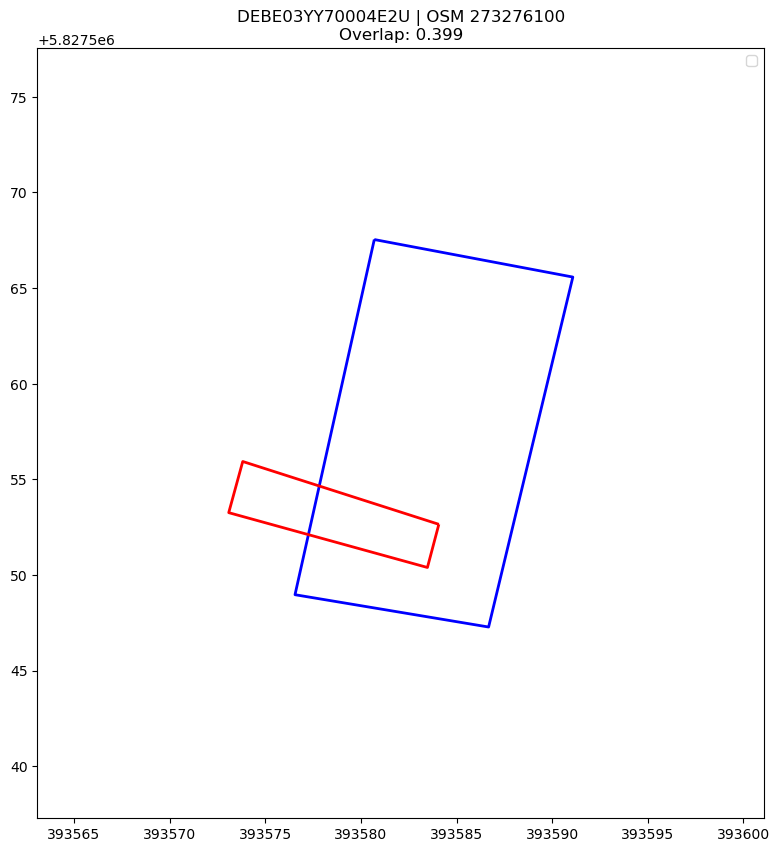

In [49]:
import matplotlib.pyplot as plt

selected_gmlid = visual_candidate["bldg_gmlid"]
selected_osm_id = int(visual_candidate["osm_id_old"])

matcad_geom = df_enriched_osm[
    df_enriched_osm["bldg_gmlid"] == selected_gmlid
].geometry.iloc[0]

osm_geom = osm_match_layer[
    osm_match_layer["osm_id_old"] == selected_osm_id
].geometry.iloc[0]

fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoSeries([osm_geom], crs="EPSG:25833").plot(
    ax=ax,
    facecolor="none",
    edgecolor="blue",
    linewidth=2,
    label="OSM 2021"
)

gpd.GeoSeries([matcad_geom], crs="EPSG:25833").plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    label="MATCAD"
)

# Tight zoom around both geometries
combined_bounds = gpd.GeoSeries(
    [osm_geom, matcad_geom],
    crs="EPSG:25833"
).total_bounds

margin = 10

ax.set_xlim(combined_bounds[0] - margin, combined_bounds[2] + margin)
ax.set_ylim(combined_bounds[1] - margin, combined_bounds[3] + margin)

ax.set_title(
    f"{selected_gmlid} | OSM {selected_osm_id}\n"
    f"Overlap: {visual_candidate['max_overlap_old']:.3f}"
)

ax.set_aspect("equal")
ax.legend()
plt.show()


In [50]:
import importlib.util

print("OSMnx installed:", importlib.util.find_spec("osmnx") is not None)

OSMnx installed: True


In [52]:
import osmnx as ox
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Selected building centroid
building_centroid = matcad_geom.centroid

# Retrieve roads around the building
roads = ox.graph_from_point(
    (building_centroid.y, building_centroid.x),
    dist=150,
    network_type="drive",
    simplify=True
)

roads_gdf = ox.graph_to_gdfs(
    roads,
    nodes=False,
    edges=True
)

print("Road segments retrieved:", len(roads_gdf))
print("Road CRS:", roads_gdf.crs)

RuntimeError: Unable to determine UTM CRS

In [53]:
from pyproj import Transformer
import osmnx as ox

# Transform MATCAD centroid from EPSG:25833 to WGS84
transformer = Transformer.from_crs(
    "EPSG:25833",
    "EPSG:4326",
    always_xy=True
)

lon, lat = transformer.transform(
    building_centroid.x,
    building_centroid.y
)

print("Latitude:", lat)
print("Longitude:", lon)

# Retrieve surrounding road network
roads = ox.graph_from_point(
    (lat, lon),
    dist=150,
    network_type="drive",
    simplify=True
)

roads_gdf = ox.graph_to_gdfs(
    roads,
    nodes=False,
    edges=True
)

print("Road segments retrieved:", len(roads_gdf))
print("Road CRS:", roads_gdf.crs)

Latitude: 52.58758352268701
Longitude: 13.429106904102708
Road segments retrieved: 18
Road CRS: epsg:4326


C:\Users\deqin\AppData\Local\Temp\ipykernel_9052\4000868617.py:57: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\deqin\AppData\Local\Temp\ipykernel_9052\4000868617.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


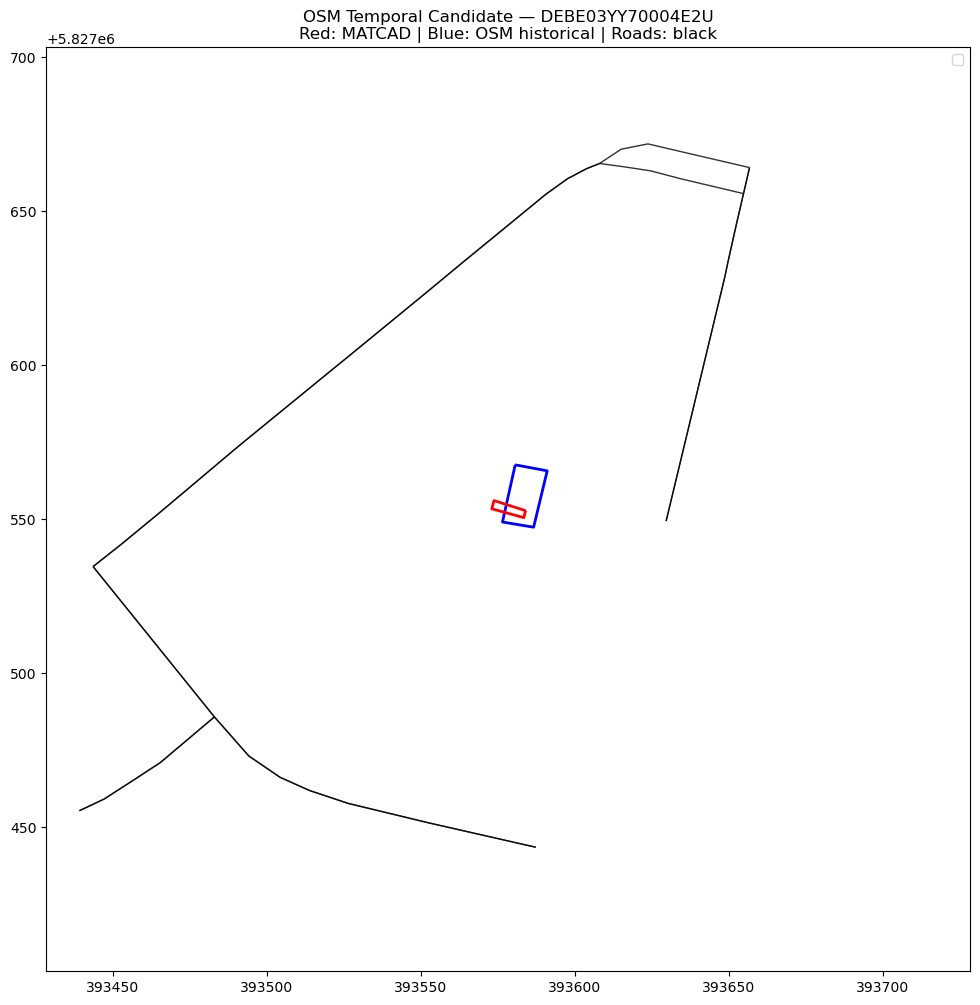

In [54]:
# Reproject roads to match the building datasets
roads_gdf_utm = roads_gdf.to_crs("EPSG:25833")

fig, ax = plt.subplots(figsize=(12, 12))

# Roads
roads_gdf_utm.plot(
    ax=ax,
    color="black",
    linewidth=1,
    alpha=0.8
)

# OSM historical footprint
gpd.GeoSeries(
    [osm_geom],
    crs="EPSG:25833"
).plot(
    ax=ax,
    facecolor="none",
    edgecolor="blue",
    linewidth=2,
    label="OSM historical footprint"
)

# MATCAD footprint
gpd.GeoSeries(
    [matcad_geom],
    crs="EPSG:25833"
).plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    label="MATCAD footprint"
)

# Zoom around building centroid
zoom_radius = 150

ax.set_xlim(
    building_centroid.x - zoom_radius,
    building_centroid.x + zoom_radius
)

ax.set_ylim(
    building_centroid.y - zoom_radius,
    building_centroid.y + zoom_radius
)

ax.set_title(
    f"OSM Temporal Candidate — {selected_gmlid}\n"
    f"Red: MATCAD | Blue: OSM historical | Roads: black"
)

ax.set_aspect("equal")
ax.legend()
plt.show()

In [55]:
# Inspect a broader sample of geometry-change candidates
candidate_sample = (
    df_enriched_osm[
        df_enriched_osm["candidate_group"] == "geometry_change_candidate"
    ][
        [
            "bldg_gmlid",
            "osm_id_old",
            "BtySig",
            "bldg_area",
            "max_overlap_old",
            "coverage_old",
            "match_status",
            "temporal_class"
        ]
    ]
    .sort_values(
        ["coverage_old", "max_overlap_old"],
        ascending=[True, True]
    )
    .head(20)
)

display(candidate_sample)

,bldg_gmlid,osm_id_old,BtySig,bldg_area,max_overlap_old,coverage_old,match_status,temporal_class
204490,DEBE12YYJ0005cxh,10301744.0,OFC,3386.74,0.001382,0.001382,one_to_one,strong_geometric_change_candidate
236570,DEBE02YY400003Ay,26491343.0,OFC,794.13,0.001537,0.001537,one_to_one,strong_geometric_change_candidate
114117,DEBE07YY90000IX2,23490720.0,ONR,457.04,0.003945,0.003945,one_to_one,strong_geometric_change_candidate
8764,DEBE12YYJ0001w72,56640546.0,ONR,42651.35,0.003691,0.006145,one_to_many,strong_geometric_change_candidate
7586,DEBE09YYO0000I8H,152892587.0,TRD,239.09,0.004794,0.007347,one_to_many,strong_geometric_change_candidate
16946,DEBE09YYO0000JkK,152892587.0,TRD,456.17,0.004794,0.007347,one_to_many,strong_geometric_change_candidate
65636,DEBE09YYO0000YIc,152892587.0,TRD,210.38,0.004794,0.007347,one_to_many,strong_geometric_change_candidate
89352,DEBE09YYO0000PPC,152892587.0,TRD,210.83,0.004794,0.007347,one_to_many,strong_geometric_change_candidate
111476,DEBE09YYO00002n8,152892587.0,TRD,163.19,0.004794,0.007347,one_to_many,strong_geometric_change_candidate
238496,DEBE09YYO0000ER4,152892587.0,TRD,386.57,0.004794,0.007347,one_to_many,strong_geometric_change_candidate


In [56]:
selected_gmlid = "DEBE02YY400003Ay"
selected_osm_id = 26491343

visual_candidate = df_enriched_osm[
    df_enriched_osm["bldg_gmlid"] == selected_gmlid
].iloc[0]

matcad_geom = df_enriched_osm[
    df_enriched_osm["bldg_gmlid"] == selected_gmlid
].geometry.iloc[0]

osm_geom = osm_match_layer[
    osm_match_layer["osm_id_old"] == selected_osm_id
].geometry.iloc[0]

building_centroid = matcad_geom.centroid

print(visual_candidate[
    [
        "bldg_gmlid",
        "osm_id_old",
        "BtySig",
        "bldg_area",
        "max_overlap_old",
        "coverage_old",
        "match_status",
        "temporal_class"
    ]
])

print("\nMATCAD geometry:", matcad_geom.geom_type)
print("OSM geometry:", osm_geom.geom_type)
print("Centroid:", building_centroid)

bldg_gmlid                          DEBE02YY400003Ay
osm_id_old                                26491343.0
BtySig                                           OFC
bldg_area                                     794.13
max_overlap_old                             0.001537
coverage_old                                0.001537
match_status                              one_to_one
temporal_class     strong_geometric_change_candidate
Name: 236570, dtype: object

MATCAD geometry: MultiPolygon
OSM geometry: MultiPolygon
Centroid: POINT (389762.65780296904 5817856.256730617)


In [57]:
from pyproj import Transformer
import osmnx as ox

building_centroid = matcad_geom.centroid

transformer = Transformer.from_crs(
    "EPSG:25833",
    "EPSG:4326",
    always_xy=True
)

lon, lat = transformer.transform(
    building_centroid.x,
    building_centroid.y
)

print("Latitude:", lat)
print("Longitude:", lon)

roads = ox.graph_from_point(
    (lat, lon),
    dist=200,
    network_type="drive",
    simplify=True
)

roads_gdf = ox.graph_to_gdfs(
    roads,
    nodes=False,
    edges=True
)

print("Road segments retrieved:", len(roads_gdf))
print("Road CRS:", roads_gdf.crs)

Latitude: 52.49968247481038
Longitude: 13.376025753337007
Road segments retrieved: 3
Road CRS: epsg:4326


C:\Users\deqin\AppData\Local\Temp\ipykernel_9052\1371414255.py:60: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\deqin\AppData\Local\Temp\ipykernel_9052\1371414255.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


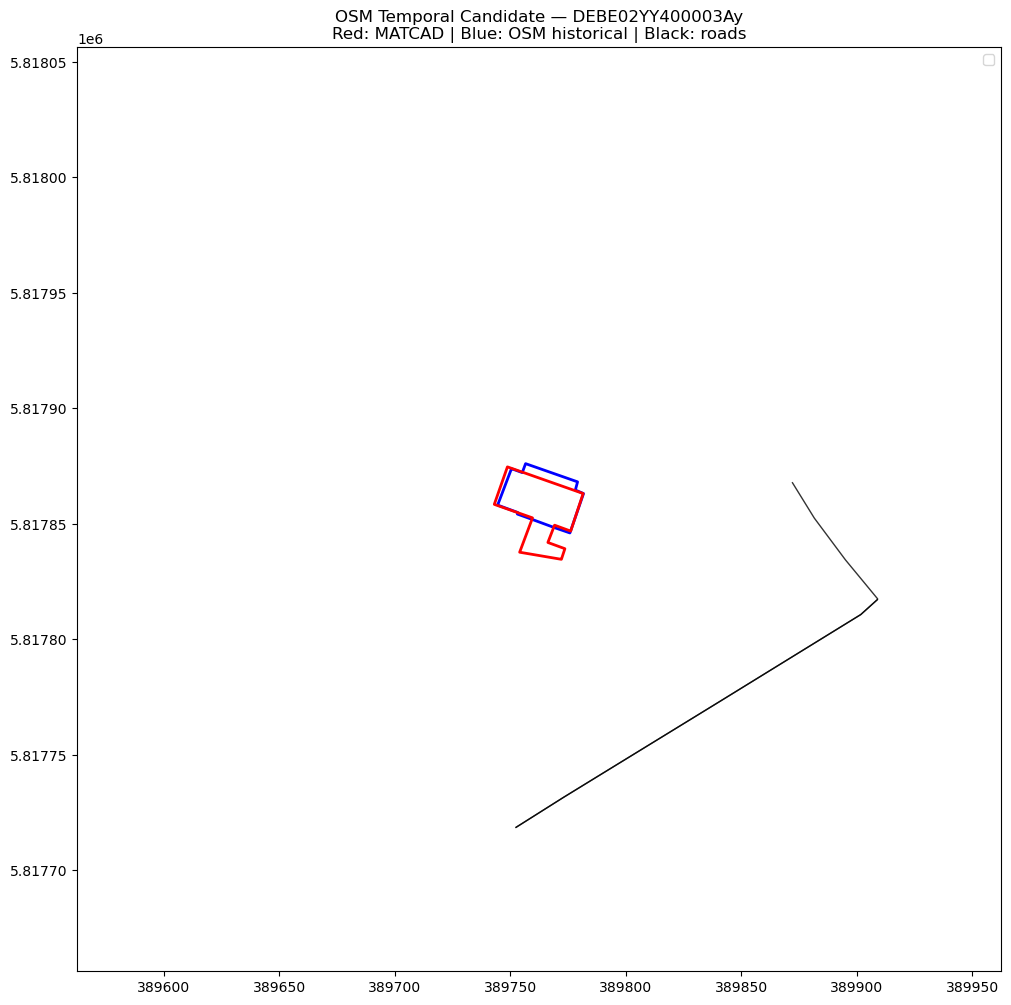

In [58]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Reproject roads to match MATCAD / OSM geometries
roads_gdf_utm = roads_gdf.to_crs("EPSG:25833")

fig, ax = plt.subplots(figsize=(12, 12))

# Surrounding roads
roads_gdf_utm.plot(
    ax=ax,
    color="black",
    linewidth=1,
    alpha=0.8
)

# Historical OSM footprint
gpd.GeoSeries(
    [osm_geom],
    crs="EPSG:25833"
).plot(
    ax=ax,
    facecolor="none",
    edgecolor="blue",
    linewidth=2,
    label="OSM historical footprint"
)

# MATCAD footprint
gpd.GeoSeries(
    [matcad_geom],
    crs="EPSG:25833"
).plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2,
    label="MATCAD footprint"
)

# Wider contextual view
zoom_radius = 200

ax.set_xlim(
    building_centroid.x - zoom_radius,
    building_centroid.x + zoom_radius
)

ax.set_ylim(
    building_centroid.y - zoom_radius,
    building_centroid.y + zoom_radius
)

ax.set_title(
    f"OSM Temporal Candidate — {selected_gmlid}\n"
    "Red: MATCAD | Blue: OSM historical | Black: roads"
)

ax.set_aspect("equal")
ax.legend()
plt.show()

In [59]:
# Inspect all columns available in the original OSM temporal register
print(osm_register_gdf.columns.tolist())

# Inspect the selected OSM temporal record
display(
    osm_register_gdf[
        osm_register_gdf["osm_id_old"] == selected_osm_id
    ]
)

['osm_id_old', 'old_area_m2', 'n_latest_matches', 'total_intersection_area_m2', 'max_overlap_old', 'max_overlap_new', 'total_overlap_old', 'coverage_old', 'match_status', 'temporal_class', 'candidate_group', 'geometry']


,osm_id_old,old_area_m2,n_latest_matches,total_intersection_area_m2,max_overlap_old,max_overlap_new,total_overlap_old,coverage_old,match_status,temporal_class,candidate_group,geometry
77543,26491343,683.732021,1,1.050698,0.001537,0.001225,0.001537,0.001537,one_to_one,strong_geometric_change_candidate,geometry_change_candidate,"MULTIPOLYGON (((389750.595 5817873.834, 389755..."


In [60]:
# List likely OSM-related GeoDataFrame variables currently loaded
[name for name in globals() if "osm" in name.lower()]

['osm_register_gdf',
 'osm_register',
 'osm_keep_cols',
 'osm_match_layer',
 'matcad_osm_centroid_match',
 'osm_attributes',
 'df_enriched_osm',
 'selected_osm_id',
 'osm_geom']

In [62]:
for name in [
    "osm_register",
    "osm_register_gdf",
    "osm_match_layer",
    "osm_keep_cols"
]:
    obj = globals().get(name)
    print(f"\n{name}")
    print("Type:", type(obj))
    
    if hasattr(obj, "shape"):
        print("Shape:", obj.shape)
    
    if hasattr(obj, "columns"):
        print("Columns:", obj.columns.tolist())


osm_register
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (632361, 11)
Columns: ['osm_id_old', 'old_area_m2', 'n_latest_matches', 'total_intersection_area_m2', 'max_overlap_old', 'max_overlap_new', 'total_overlap_old', 'coverage_old', 'match_status', 'temporal_class', 'candidate_group']

osm_register_gdf
Type: <class 'geopandas.geodataframe.GeoDataFrame'>
Shape: (632361, 12)
Columns: ['osm_id_old', 'old_area_m2', 'n_latest_matches', 'total_intersection_area_m2', 'max_overlap_old', 'max_overlap_new', 'total_overlap_old', 'coverage_old', 'match_status', 'temporal_class', 'candidate_group', 'geometry']

osm_match_layer
Type: <class 'geopandas.geodataframe.GeoDataFrame'>
Shape: (632361, 9)
Columns: ['osm_id_old', 'n_latest_matches', 'max_overlap_old', 'max_overlap_new', 'coverage_old', 'match_status', 'temporal_class', 'candidate_group', 'geometry']

osm_keep_cols
Type: <class 'list'>


In [63]:
import geopandas as gpd

geo_objects = []

for name, obj in globals().items():
    if isinstance(obj, gpd.GeoDataFrame):
        geo_objects.append({
            "variable": name,
            "shape": obj.shape,
            "crs": str(obj.crs),
            "columns": list(obj.columns)
        })

display(geo_objects)

[{'variable': 'osm_register_gdf',
  'shape': (632361, 12),
  'crs': 'EPSG:25833',
  'columns': ['osm_id_old',
   'old_area_m2',
   'n_latest_matches',
   'total_intersection_area_m2',
   'max_overlap_old',
   'max_overlap_new',
   'total_overlap_old',
   'coverage_old',
   'match_status',
   'temporal_class',
   'candidate_group',
   'geometry']},
 {'variable': '_3',
  'shape': (5, 12),
  'crs': 'EPSG:25833',
  'columns': ['osm_id_old',
   'old_area_m2',
   'n_latest_matches',
   'total_intersection_area_m2',
   'max_overlap_old',
   'max_overlap_new',
   'total_overlap_old',
   'coverage_old',
   'match_status',
   'temporal_class',
   'candidate_group',
   'geometry']},
 {'variable': 'disappearance_candidates',
  'shape': (9156, 12),
  'crs': 'EPSG:25833',
  'columns': ['osm_id_old',
   'old_area_m2',
   'n_latest_matches',
   'total_intersection_area_m2',
   'max_overlap_old',
   'max_overlap_new',
   'total_overlap_old',
   'coverage_old',
   'match_status',
   'temporal_class',
  

In [64]:
# Inspect non-GeoDataFrame variables whose names may belong to the OSM temporal workflow
[
    name for name in globals()
    if any(
        key in name.lower()
        for key in [
            "latest",
            "old",
            "new",
            "matched",
            "intersection",
            "temporal",
            "building"
        ]
    )
]

['building_centroid']

In [65]:
[
    name for name in globals()
    if any(
        key in name.lower()
        for key in [
            "osm",
            "building",
            "latest",
            "gdf",
            "path",
            "file",
            "parquet",
            "gpkg",
            "geojson"
        ]
    )
]

['Path',
 'csv_path',
 'gpkg_path',
 'osm_register_gdf',
 'osm_register',
 'matcad_path',
 'matcad_enriched_path',
 'gpkg',
 'df_enriched_gdf',
 'invalid_gdf',
 'output_path',
 'osm_keep_cols',
 'osm_match_layer',
 'matcad_osm_centroid_match',
 'osm_attributes',
 'df_enriched_osm',
 'selected_osm_id',
 'osm_geom',
 'building_centroid',
 'roads_gdf',
 'roads_gdf_utm']

In [66]:
type(osm_attributes), getattr(osm_attributes, "shape", None), getattr(osm_attributes, "columns", None)

(pandas.core.frame.DataFrame,
 (327295, 9),
 Index(['bldg_gmlid', 'osm_id_old', 'n_latest_matches', 'max_overlap_old',
        'max_overlap_new', 'coverage_old', 'match_status', 'temporal_class',
        'candidate_group'],
       dtype='object'))

In [67]:
for name in ["Path", "csv_path", "gpkg_path", "matcad_path", "matcad_enriched_path", "output_path"]:
    obj = globals().get(name, None)
    print(f"{name}: {obj}")

Path: <class 'pathlib.Path'>
csv_path: C:\Users\deqin\osm_temporal_outputs\osm_temporal_change_register_2021_latest.csv
gpkg_path: C:\Users\deqin\Downloads\matcad2022_de-be_bfp_mps1.gpkg
matcad_path: C:\Users\deqin\Downloads\matcad2022_de-be_bfp_mps1_cleaned.gpkg
matcad_enriched_path: C:\Users\deqin\Downloads\MATCAD_Energy_Age_Denkmal_PopPressure_Abriss.gpkg
output_path: C:\Users\deqin\osm_temporal_outputs\matcad_enriched_spatial.gpkg


In [68]:
import fiona

temporal_gpkg = r"osm_temporal_outputs\osm_temporal_change_register_2021_latest.gpkg"

print("Available layers:")
for layer in fiona.listlayers(temporal_gpkg):
    print(" -", layer)

Available layers:
 - osm_temporal_register
 - disappearance_candidates
 - geometry_change_candidates


In [69]:
type(matcad_osm_centroid_match), matcad_osm_centroid_match.shape, matcad_osm_centroid_match.columns.tolist()

(geopandas.geodataframe.GeoDataFrame,
 (327295, 11),
 ['bldg_gmlid',
  'geometry',
  'index_osm',
  'osm_id_old',
  'n_latest_matches',
  'max_overlap_old',
  'max_overlap_new',
  'coverage_old',
  'match_status',
  'temporal_class',
  'candidate_group'])

In [70]:
display(
    matcad_osm_centroid_match["candidate_group"]
    .value_counts(dropna=False)
    .to_frame("count")
)

,count
candidate_group,
persistent_building,302336
NaN,23229
disappearance_or_no_match_candidate,993
geometry_change_candidate,737


In [71]:
candidate_mask = matcad_osm_centroid_match["candidate_group"].isin(
    [
        "disappearance_or_no_match_candidate",
        "geometry_change_candidate"
    ]
)

display(
    matcad_osm_centroid_match.loc[candidate_mask, "candidate_group"]
    .value_counts()
)

print("\nCandidate buildings by type:")
display(
    df_enriched_osm.loc[
        candidate_mask,
        "BtySig"
    ].value_counts(dropna=False).to_frame("count")
)

candidate_group
disappearance_or_no_match_candidate    993
geometry_change_candidate              737
Name: count, dtype: int64


Candidate buildings by type:


,count
BtySig,
SFH,646
STG,237
PRO,199
NAS,191
MFH,120
TRD,112
ONR,101
OFC,92
HOT,20


In [72]:
print("Same index:", matcad_osm_centroid_match.index.equals(df_enriched_osm.index))
print("Same row count:", len(matcad_osm_centroid_match) == len(df_enriched_osm))

print(
    "Same bldg_gmlid sequence:",
    matcad_osm_centroid_match["bldg_gmlid"].reset_index(drop=True).equals(
        df_enriched_osm["bldg_gmlid"].reset_index(drop=True)
    )
)

Same index: False
Same row count: True
Same bldg_gmlid sequence: False


In [73]:
print(
    "Overlay unique bldg_gmlid:",
    matcad_osm_centroid_match["bldg_gmlid"].is_unique
)

print(
    "MATCAD enriched unique bldg_gmlid:",
    df_enriched_osm["bldg_gmlid"].is_unique
)

print(
    "Overlay duplicate IDs:",
    matcad_osm_centroid_match["bldg_gmlid"].duplicated().sum()
)

print(
    "MATCAD duplicate IDs:",
    df_enriched_osm["bldg_gmlid"].duplicated().sum()
)

Overlay unique bldg_gmlid: True
MATCAD enriched unique bldg_gmlid: True
Overlay duplicate IDs: 0
MATCAD duplicate IDs: 0


In [74]:
# Join MATCAD attributes onto the OSM-derived centroid overlay
matcad_attributes = df_enriched_osm.drop(
    columns="geometry",
    errors="ignore"
)

osm_matcad_overlay = matcad_osm_centroid_match.merge(
    matcad_attributes,
    on="bldg_gmlid",
    how="left",
    suffixes=("", "_matcad")
)

print("Shape:", osm_matcad_overlay.shape)
print("Unique building IDs:", osm_matcad_overlay["bldg_gmlid"].is_unique)

display(osm_matcad_overlay.head())

Shape: (327295, 41)
Unique building IDs: True


,bldg_gmlid,geometry,index_osm,osm_id_old,n_latest_matches,max_overlap_old,max_overlap_new,coverage_old,match_status,temporal_class,...,age_data_available,density_change_available,osm_id_old_matcad,n_latest_matches_matcad,max_overlap_old_matcad,max_overlap_new_matcad,coverage_old_matcad,match_status_matcad,temporal_class_matcad,candidate_group_matcad
0,DEBE00YY10z0001A,POINT (405785.076 5818070.703),588555.0,422272387.0,1.0,1.000000,1.0,1.000000,one_to_one,strong_geometric_persistence,...,0,1,422272387.0,1.0,1.000000,1.0,1.000000,one_to_one,strong_geometric_persistence,persistent_building
1,DEBE00YY10z0001Q,POINT (405783.743 5818054.813),588555.0,422272387.0,1.0,1.000000,1.0,1.000000,one_to_one,strong_geometric_persistence,...,0,1,422272387.0,1.0,1.000000,1.0,1.000000,one_to_one,strong_geometric_persistence,persistent_building
2,DEBE00YY1110002O,POINT (396770.323 5808653.716),494179.0,258654498.0,1.0,1.000000,1.0,1.000000,one_to_one,strong_geometric_persistence,...,1,1,258654498.0,1.0,1.000000,1.0,1.000000,one_to_one,strong_geometric_persistence,persistent_building
3,DEBE00YY1110005I,POINT (409840.051 5807551.966),502141.0,527510969.0,1.0,0.723062,1.0,0.723062,one_to_one,partial_or_modified_geometry,...,1,1,527510969.0,1.0,0.723062,1.0,0.723062,one_to_one,partial_or_modified_geometry,persistent_building
4,DEBE00YY11100066,POINT (383126.541 5823819.856),244667.0,134815056.0,1.0,1.000000,1.0,1.000000,one_to_one,strong_geometric_persistence,...,1,1,134815056.0,1.0,1.000000,1.0,1.000000,one_to_one,strong_geometric_persistence,persistent_building


In [75]:
for i, col in enumerate(osm_matcad_overlay.columns):
    print(i, col)

0 bldg_gmlid
1 geometry
2 index_osm
3 osm_id_old
4 n_latest_matches
5 max_overlap_old
6 max_overlap_new
7 coverage_old
8 match_status
9 temporal_class
10 candidate_group
11 building_serial_id
12 bldg_area
13 bldg_volume
14 BtySig
15 energy_intensity_kwh_m3a
16 denkmal_status
17 pop_density_pressure_change
18 pop_density_pressure_pct_change
19 reporting_of_demolition
20 number_of_age_periods
21 dominant_age_share
22 dominant_age_period_label
23 dominant_age_midpoint
24 weighted_average_construction_year
25 weighted_average_age_2015
26 dominant_age_2015
27 earliest_age_midpoint
28 latest_age_midpoint
29 age_distribution_range
30 demolition_target
31 age_data_available
32 density_change_available
33 osm_id_old_matcad
34 n_latest_matches_matcad
35 max_overlap_old_matcad
36 max_overlap_new_matcad
37 coverage_old_matcad
38 match_status_matcad
39 temporal_class_matcad
40 candidate_group_matcad


In [76]:
# Remove redundant duplicated OSM fields created by the merge
duplicate_osm_cols = [
    "osm_id_old_matcad",
    "n_latest_matches_matcad",
    "max_overlap_old_matcad",
    "max_overlap_new_matcad",
    "coverage_old_matcad",
    "match_status_matcad",
    "temporal_class_matcad",
    "candidate_group_matcad",
]

osm_matcad_overlay_clean = osm_matcad_overlay.drop(
    columns=duplicate_osm_cols
)

print("Shape:", osm_matcad_overlay_clean.shape)
print("\nColumns:")
for i, col in enumerate(osm_matcad_overlay_clean.columns):
    print(i, col)

Shape: (327295, 33)

Columns:
0 bldg_gmlid
1 geometry
2 index_osm
3 osm_id_old
4 n_latest_matches
5 max_overlap_old
6 max_overlap_new
7 coverage_old
8 match_status
9 temporal_class
10 candidate_group
11 building_serial_id
12 bldg_area
13 bldg_volume
14 BtySig
15 energy_intensity_kwh_m3a
16 denkmal_status
17 pop_density_pressure_change
18 pop_density_pressure_pct_change
19 reporting_of_demolition
20 number_of_age_periods
21 dominant_age_share
22 dominant_age_period_label
23 dominant_age_midpoint
24 weighted_average_construction_year
25 weighted_average_age_2015
26 dominant_age_2015
27 earliest_age_midpoint
28 latest_age_midpoint
29 age_distribution_range
30 demolition_target
31 age_data_available
32 density_change_available


In [77]:
print(
    osm_matcad_overlay_clean["candidate_group"]
    .value_counts(dropna=False)
)

candidate_group
persistent_building                    302336
NaN                                     23229
disappearance_or_no_match_candidate       993
geometry_change_candidate                 737
Name: count, dtype: int64


In [78]:
# Restrict to buildings with an assigned OSM temporal classification
classified = osm_matcad_overlay_clean[
    osm_matcad_overlay_clean["candidate_group"].notna()
].copy()

# Total classified buildings by type
type_totals = (
    classified
    .groupby("BtySig")
    .size()
    .rename("total_classified")
)

# Temporal-change candidates by type
candidate_types = classified[
    classified["candidate_group"].isin([
        "disappearance_or_no_match_candidate",
        "geometry_change_candidate"
    ])
]

type_candidates = (
    candidate_types
    .groupby("BtySig")
    .size()
    .rename("temporal_candidates")
)

candidate_rate_by_type = (
    pd.concat([type_totals, type_candidates], axis=1)
    .fillna(0)
)

candidate_rate_by_type["temporal_candidate_rate_pct"] = (
    candidate_rate_by_type["temporal_candidates"]
    / candidate_rate_by_type["total_classified"]
    * 100
)

candidate_rate_by_type = candidate_rate_by_type.sort_values(
    "temporal_candidate_rate_pct",
    ascending=False
)

display(candidate_rate_by_type)

,total_classified,temporal_candidates,temporal_candidate_rate_pct
BtySig,,,
STG,4160,237,5.697115
PRO,7115,199,2.796908
TRD,4033,112,2.777089
OFC,4259,92,2.160131
NAS,10348,191,1.845767
HOT,1205,20,1.659751
ONR,7652,101,1.319916
HSN,1221,11,0.900901
ASB,137,1,0.729927


In [80]:
candidate_breakdown_by_type = pd.crosstab(
    classified["BtySig"],
    classified["candidate_group"]
)

candidate_breakdown_by_type["total_temporal_candidates"] = (
    candidate_breakdown_by_type
    .get("disappearance_or_no_match_candidate", 0)
    +
    candidate_breakdown_by_type
    .get("geometry_change_candidate", 0)
)

display(
    candidate_breakdown_by_type.sort_values(
        "total_temporal_candidates",
        ascending=False
    )
)

candidate_group,disappearance_or_no_match_candidate,geometry_change_candidate,persistent_building,total_temporal_candidates
BtySig,,,,
SFH,220,426,167348,646
STG,199,38,3923,237
PRO,158,41,6916,199
NAS,118,73,10157,191
MFH,61,59,95822,120
TRD,82,30,3921,112
ONR,67,34,7551,101
OFC,64,28,4167,92
HOT,14,6,1185,20


In [81]:
# Separate candidate counts by building type
candidate_rate_separate = (
    classified
    .groupby("BtySig")
    .size()
    .rename("total_classified")
    .to_frame()
)

for candidate_class, short_name in [
    ("disappearance_or_no_match_candidate", "disappearance"),
    ("geometry_change_candidate", "geometry_change"),
]:
    counts = (
        classified[classified["candidate_group"] == candidate_class]
        .groupby("BtySig")
        .size()
        .rename(f"{short_name}_count")
    )

    candidate_rate_separate = candidate_rate_separate.join(
        counts,
        how="left"
    )

candidate_rate_separate = candidate_rate_separate.fillna(0)

candidate_rate_separate["disappearance_rate_pct"] = (
    candidate_rate_separate["disappearance_count"]
    / candidate_rate_separate["total_classified"]
    * 100
)

candidate_rate_separate["geometry_change_rate_pct"] = (
    candidate_rate_separate["geometry_change_count"]
    / candidate_rate_separate["total_classified"]
    * 100
)

candidate_rate_separate["total_temporal_rate_pct"] = (
    (
        candidate_rate_separate["disappearance_count"]
        + candidate_rate_separate["geometry_change_count"]
    )
    / candidate_rate_separate["total_classified"]
    * 100
)

display(
    candidate_rate_separate.sort_values(
        "total_temporal_rate_pct",
        ascending=False
    )
)

,total_classified,disappearance_count,geometry_change_count,disappearance_rate_pct,geometry_change_rate_pct,total_temporal_rate_pct
BtySig,,,,,,
STG,4160,199,38.0,4.783654,0.913462,5.697115
PRO,7115,158,41.0,2.220661,0.576247,2.796908
TRD,4033,82,30.0,2.033226,0.743863,2.777089
OFC,4259,64,28.0,1.502700,0.657431,2.160131
NAS,10348,118,73.0,1.140317,0.705450,1.845767
HOT,1205,14,6.0,1.161826,0.497925,1.659751
ONR,7652,67,34.0,0.875588,0.444328,1.319916
HSN,1221,9,2.0,0.737101,0.163800,0.900901
ASB,137,1,0.0,0.729927,0.000000,0.729927


In [82]:
# Create an independent analysis dataframe
osm_matcad_analysis = osm_matcad_overlay_clean.copy()

# Separate OSM-derived target indicators
osm_matcad_analysis["osm_disappearance_candidate"] = (
    osm_matcad_analysis["candidate_group"]
    == "disappearance_or_no_match_candidate"
).astype("int8")

osm_matcad_analysis["osm_geometry_change_candidate"] = (
    osm_matcad_analysis["candidate_group"]
    == "geometry_change_candidate"
).astype("int8")

# Broad temporal-change indicator
osm_matcad_analysis["osm_any_temporal_change_candidate"] = (
    osm_matcad_analysis["candidate_group"].isin([
        "disappearance_or_no_match_candidate",
        "geometry_change_candidate"
    ])
).astype("int8")

print("Shape:", osm_matcad_analysis.shape)

display(
    osm_matcad_analysis[
        [
            "candidate_group",
            "osm_disappearance_candidate",
            "osm_geometry_change_candidate",
            "osm_any_temporal_change_candidate"
        ]
    ].head()
)

Shape: (327295, 36)


,candidate_group,osm_disappearance_candidate,osm_geometry_change_candidate,osm_any_temporal_change_candidate
0,persistent_building,0,0,0
1,persistent_building,0,0,0
2,persistent_building,0,0,0
3,persistent_building,0,0,0
4,persistent_building,0,0,0


In [83]:
# Preserve unclassified OSM records as missing rather than treating them as persistent

unclassified_mask = (
    osm_matcad_analysis["candidate_group"].isna()
)

target_columns = [
    "osm_disappearance_candidate",
    "osm_geometry_change_candidate",
    "osm_any_temporal_change_candidate"
]

osm_matcad_analysis.loc[
    unclassified_mask,
    target_columns
] = pd.NA

# Use nullable integer type
for col in target_columns:
    osm_matcad_analysis[col] = (
        osm_matcad_analysis[col].astype("Int8")
    )

display(
    osm_matcad_analysis["candidate_group"]
    .value_counts(dropna=False)
)

print("\nMissing values in derived targets:")
display(
    osm_matcad_analysis[target_columns]
    .isna()
    .sum()
)

candidate_group
persistent_building                    302336
NaN                                     23229
disappearance_or_no_match_candidate       993
geometry_change_candidate                 737
Name: count, dtype: int64


Missing values in derived targets:


osm_disappearance_candidate          23229
osm_geometry_change_candidate        23229
osm_any_temporal_change_candidate    23229
dtype: int64

In [84]:
# Verify derived target distributions

for col in target_columns:
    print(f"\n{col}")
    display(
        osm_matcad_analysis[col]
        .value_counts(dropna=False)
        .sort_index()
    )


osm_disappearance_candidate


osm_disappearance_candidate
0       303073
1          993
<NA>     23229
Name: count, dtype: Int64


osm_geometry_change_candidate


osm_geometry_change_candidate
0       303329
1          737
<NA>     23229
Name: count, dtype: Int64


osm_any_temporal_change_candidate


osm_any_temporal_change_candidate
0       302336
1         1730
<NA>     23229
Name: count, dtype: Int64

In [85]:
# Distribution of any temporal-change candidates by MATCAD building type

temporal_by_type = (
    osm_matcad_analysis[
        osm_matcad_analysis["osm_any_temporal_change_candidate"].notna()
    ]
    .groupby("BtySig")["osm_any_temporal_change_candidate"]
    .agg(
        total_classified="count",
        temporal_candidates="sum"
    )
    .reset_index()
)

temporal_by_type["temporal_candidate_rate_pct"] = (
    temporal_by_type["temporal_candidates"]
    / temporal_by_type["total_classified"]
    * 100
)

temporal_by_type = temporal_by_type.sort_values(
    "temporal_candidate_rate_pct",
    ascending=False
)

display(temporal_by_type)

,BtySig,total_classified,temporal_candidates,temporal_candidate_rate_pct
9,STG,4160,237,5.697115
7,PRO,7115,199,2.796908
10,TRD,4033,112,2.777089
5,OFC,4259,92,2.160131
4,NAS,10348,191,1.845767
1,HOT,1205,20,1.659751
6,ONR,7652,101,1.319916
2,HSN,1221,11,0.900901
0,ASB,137,1,0.729927
8,SFH,167994,646,0.384538


In [86]:
# Save normalized temporal-change rates by building type

temporal_by_type.to_csv(
    "osm_temporal_change_rates_by_building_type.csv",
    index=False
)

print("Saved:", "osm_temporal_change_rates_by_building_type.csv")

Saved: osm_temporal_change_rates_by_building_type.csv


In [87]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFull CSV path:")
print(
    os.path.abspath(
        "osm_temporal_change_rates_by_building_type.csv"
    )
)

Current working directory:
C:\Users\deqin

Full CSV path:
C:\Users\deqin\osm_temporal_change_rates_by_building_type.csv


In [88]:
# Create a readable three-group OSM temporal status

osm_matcad_analysis["osm_temporal_status"] = (
    osm_matcad_analysis["candidate_group"]
    .map({
        "persistent_building": "Persistent classified",
        "disappearance_or_no_match_candidate": "Disappearance/no-match candidate",
        "geometry_change_candidate": "Geometry-change candidate"
    })
    .fillna("Unclassified")
)

display(
    osm_matcad_analysis["osm_temporal_status"]
    .value_counts()
)

osm_temporal_status
Persistent classified               302336
Unclassified                         23229
Disappearance/no-match candidate       993
Geometry-change candidate              737
Name: count, dtype: int64

In [89]:
# Compare key building attributes across OSM temporal-status groups

comparison_columns = [
    "bldg_area",
    "bldg_volume",
    "energy_intensity_kwh_m3a",
    "weighted_average_age_2015",
    "dominant_age_2015",
    "dominant_age_midpoint",
    "age_distribution_range",
    "pop_density_pressure_pct_change"
]

status_summary = (
    osm_matcad_analysis
    .groupby("osm_temporal_status")[comparison_columns]
    .agg(["count", "mean", "median", "std"])
)

display(status_summary)

bldg_area                                   \
                                     count        mean  median          std   
osm_temporal_status                                                           
Disappearance/no-match candidate       993  516.302951  166.57  1443.537202   
Geometry-change candidate              737  353.450299   94.51  1950.594559   
Persistent classified               302336  230.466338  112.55   627.251348   
Unclassified                         23229  438.767524  135.18  1014.984400   

                                 bldg_volume                        \
                                       count         mean   median   
osm_temporal_status                                                  
Disappearance/no-match candidate         993  4961.247382  960.990   
Geometry-change candidate                737  3276.658792  543.010   
Persistent classified                 302336  2953.887492  777.195   
Unclassified                           23229  7742.587086  839.040   

                                               energy_intensity_kwh_m3a  \
                                           std                    count   
osm_temporal_status                                                       
Disappearance/no-match candidate  14395.585371                      993   
Geometry-change candidate         19100.529672                      737   
Persistent classified             10096.290847                   302336   
Unclassified                      20342.732104                    23229   

                                             ... dominant_age_midpoint  \
                                       mean  ...                median   
osm_temporal_status                          ...                         
Disappearance/no-match candidate  22.726922  ...                1955.0   
Geometry-change candidate         23.831166  ...                1975.0   
Persistent classified             19.936818  ...                1965.0   
Unclassified                      23.210092  ...                1945.0   

                                            age_distribution_range             \
                                        std                  count       mean   
osm_temporal_status                                                             
Disappearance/no-match candidate  38.104367                    594  77.227273   
Geometry-change candidate         33.214257                    610  80.588525   
Persistent classified             34.703172                 260412  74.076129   
Unclassified                      39.528081                  15398  78.958306   

                                                    \
                                 median        std   
osm_temporal_status                                  
Disappearance/no-match candidate   80.0  32.184709   
Geometry-change candidate          80.0  27.822618   
Persistent classified              80.0  32.564606   
Unclassified                       80.0  29.765555   

                                 pop_density_pressure_pct_change             \
                                                           count       mean   
osm_temporal_status                                                           
Disappearance/no-match candidate                             724  64.846628   
Geometry-change candidate                                    653  48.406398   
Persistent classified                                     286875  35.672643   
Unclassified                                               21074  52.562675   

                                                        
                                    median         std  
osm_temporal_status                                     
Disappearance/no-match candidate  3.077369  468.035398  
Geometry-change candidate         4.113636  469.020779  
Persistent classified             3.177112  499.566535  
Unclassified                      5.047733  819.793616  

[4 rows x 32 columns]

In [90]:
# Clean, readable median comparison by OSM temporal status

summary_variables = [
    "bldg_area",
    "bldg_volume",
    "energy_intensity_kwh_m3a",
    "weighted_average_age_2015",
    "dominant_age_2015",
    "dominant_age_midpoint",
    "age_distribution_range",
    "pop_density_pressure_pct_change"
]

compact_summary = (
    osm_matcad_analysis
    .groupby("osm_temporal_status")[summary_variables]
    .agg(["count", "median"])
)

# Flatten column names
compact_summary.columns = [
    f"{col}_{stat}"
    for col, stat in compact_summary.columns
]

compact_summary = compact_summary.reset_index()

display(compact_summary)

,osm_temporal_status,bldg_area_count,bldg_area_median,bldg_volume_count,bldg_volume_median,energy_intensity_kwh_m3a_count,energy_intensity_kwh_m3a_median,weighted_average_age_2015_count,weighted_average_age_2015_median,dominant_age_2015_count,dominant_age_2015_median,dominant_age_midpoint_count,dominant_age_midpoint_median,age_distribution_range_count,age_distribution_range_median,pop_density_pressure_pct_change_count,pop_density_pressure_pct_change_median
0,Disappearance/no-match candidate,993,166.57,993,960.990,993,18.533474,594,58.000000,594,60.0,594,1955.0,594,80.0,724,3.077369
1,Geometry-change candidate,737,94.51,737,543.010,737,20.438536,610,48.333333,610,40.0,610,1975.0,610,80.0,653,4.113636
2,Persistent classified,302336,112.55,302336,777.195,302336,18.650489,260412,52.307692,260412,50.0,260412,1965.0,260412,80.0,286875,3.177112
3,Unclassified,23229,135.18,23229,839.040,23229,19.699454,15398,59.314263,15398,70.0,15398,1945.0,15398,80.0,21074,5.047733


In [91]:
# Prepare clean data for bootstrap confidence intervals

pressure_col = "pop_density_pressure_pct_change"

pressure_data = osm_matcad_analysis[
    osm_matcad_analysis["osm_temporal_status"].isin([
        "Disappearance/no-match candidate",
        "Geometry-change candidate",
        "Persistent classified"
    ])
][
    ["osm_temporal_status", pressure_col]
].dropna()

print("Records available:", len(pressure_data))

display(
    pressure_data["osm_temporal_status"]
    .value_counts()
)

Records available: 288252


osm_temporal_status
Persistent classified               286875
Disappearance/no-match candidate       724
Geometry-change candidate              653
Name: count, dtype: int64

In [92]:
import numpy as np
import pandas as pd

def bootstrap_median_ci(values, n_boot=5000, ci=95, seed=42):
    """
    Bootstrap confidence interval for the median.
    """
    values = np.asarray(values.dropna())

    rng = np.random.default_rng(seed)

    bootstrap_medians = np.array([
        np.median(
            rng.choice(values, size=len(values), replace=True)
        )
        for _ in range(n_boot)
    ])

    alpha = (100 - ci) / 2

    lower = np.percentile(bootstrap_medians, alpha)
    upper = np.percentile(bootstrap_medians, 100 - alpha)

    return {
        "n": len(values),
        "median": np.median(values),
        "ci_lower": lower,
        "ci_upper": upper
    }


bootstrap_results = []

for status, group in pressure_data.groupby("osm_temporal_status"):

    result = bootstrap_median_ci(
        group[pressure_col],
        n_boot=5000,
        ci=95,
        seed=42
    )

    result["osm_temporal_status"] = status
    bootstrap_results.append(result)


bootstrap_ci_summary = pd.DataFrame(
    bootstrap_results
)[
    [
        "osm_temporal_status",
        "n",
        "median",
        "ci_lower",
        "ci_upper"
    ]
].sort_values("median")

display(bootstrap_ci_summary)

,osm_temporal_status,n,median,ci_lower,ci_upper
0,Disappearance/no-match candidate,724,3.077369,1.940816,4.549323
2,Persistent classified,286875,3.177112,3.117484,3.258621
1,Geometry-change candidate,653,4.113636,3.409091,6.000000


In [93]:
def bootstrap_median_difference_ci(
    values_a,
    values_b,
    n_boot=5000,
    ci=95,
    seed=42
):
    """
    Bootstrap CI for the difference in independent-group medians:
    median(A) - median(B)
    """

    values_a = np.asarray(values_a.dropna())
    values_b = np.asarray(values_b.dropna())

    rng = np.random.default_rng(seed)

    observed_difference = (
        np.median(values_a) - np.median(values_b)
    )

    bootstrap_differences = np.empty(n_boot)

    for i in range(n_boot):
        sample_a = rng.choice(
            values_a,
            size=len(values_a),
            replace=True
        )

        sample_b = rng.choice(
            values_b,
            size=len(values_b),
            replace=True
        )

        bootstrap_differences[i] = (
            np.median(sample_a) - np.median(sample_b)
        )

    alpha = (100 - ci) / 2

    return {
        "difference_median": observed_difference,
        "ci_lower": np.percentile(
            bootstrap_differences,
            alpha
        ),
        "ci_upper": np.percentile(
            bootstrap_differences,
            100 - alpha
        )
    }


persistent_values = pressure_data.loc[
    pressure_data["osm_temporal_status"] == "Persistent classified",
    pressure_col
]

disappearance_values = pressure_data.loc[
    pressure_data["osm_temporal_status"] == "Disappearance/no-match candidate",
    pressure_col
]

geometry_values = pressure_data.loc[
    pressure_data["osm_temporal_status"] == "Geometry-change candidate",
    pressure_col
]


difference_results = []

for label, candidate_values in [
    ("Disappearance - Persistent", disappearance_values),
    ("Geometry-change - Persistent", geometry_values)
]:

    result = bootstrap_median_difference_ci(
        candidate_values,
        persistent_values,
        n_boot=5000,
        ci=95,
        seed=42
    )

    result["comparison"] = label
    difference_results.append(result)


median_difference_summary = pd.DataFrame(
    difference_results
)[
    [
        "comparison",
        "difference_median",
        "ci_lower",
        "ci_upper"
    ]
]

display(median_difference_summary)

,comparison,difference_median,ci_lower,ci_upper
0,Disappearance - Persistent,-0.099742,-1.214291,1.403220
1,Geometry-change - Persistent,0.936525,0.262022,2.775268


In [94]:
energy_col = "energy_intensity_kwh_m3a"

print("Total records:", len(osm_matcad_analysis))

print("\nMissing energy values:")
print(
    osm_matcad_analysis[energy_col]
    .isna()
    .sum()
)

print("\nEnergy statistics:")
display(
    osm_matcad_analysis[energy_col]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
)

Total records: 327295

Missing energy values:
0

Energy statistics:


count    327295.000000
mean         20.186365
std          10.859436
min           0.740552
1%            8.303902
5%           10.584471
25%          14.764088
50%          18.706468
75%          22.903596
95%          32.637400
99%          64.547923
max         494.555647
Name: energy_intensity_kwh_m3a, dtype: float64

In [95]:
# Energy intensity distribution by MATCAD building type

energy_by_type = (
    osm_matcad_analysis
    .groupby("BtySig")[energy_col]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        p05=lambda x: x.quantile(0.05),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        maximum="max"
    )
    .reset_index()
    .sort_values("median")
)

display(energy_by_type)

,BtySig,count,mean,median,std,p05,p95,p99,maximum
9,STG,4716,13.367656,12.956518,7.364519,6.285429,21.191311,25.355972,281.762120
7,PRO,7867,16.373995,13.452181,13.899244,7.224584,37.937747,56.634703,446.796827
0,ASB,178,24.316467,15.548486,36.484488,8.429459,92.436769,216.656540,251.651015
10,TRD,4294,18.023941,16.464379,9.739382,9.006230,34.884583,41.921653,323.492335
3,MFH,104852,18.709737,18.219765,3.803148,13.626160,25.052760,29.367369,90.508000
8,SFH,172854,18.601400,18.542442,6.142795,10.519020,28.920521,34.158919,284.625575
5,OFC,4759,21.499537,20.206577,17.471409,11.302893,30.555305,54.316896,479.277365
4,NAS,16343,28.349116,28.752708,11.928540,8.694002,38.091022,56.452374,448.917817
2,HSN,1359,34.166508,29.469954,18.934194,15.119563,64.422768,91.844800,319.110590
6,ONR,8724,51.866519,49.173756,31.750350,18.387170,87.586026,153.496105,494.555647


In [96]:
# Calculate type-specific 99th-percentile thresholds
# and count observations above each threshold

type_energy_thresholds = (
    osm_matcad_analysis
    .groupby("BtySig")[energy_col]
    .quantile(0.99)
    .rename("energy_p99")
    .reset_index()
)

osm_matcad_energy_check = osm_matcad_analysis.merge(
    type_energy_thresholds,
    on="BtySig",
    how="left"
)

osm_matcad_energy_check["above_type_p99"] = (
    osm_matcad_energy_check[energy_col]
    > osm_matcad_energy_check["energy_p99"]
)

energy_trim_summary = (
    osm_matcad_energy_check
    .groupby("BtySig")
    .agg(
        total=("energy_intensity_kwh_m3a", "count"),
        p99_threshold=("energy_p99", "first"),
        above_p99=("above_type_p99", "sum")
    )
    .reset_index()
)

energy_trim_summary["removed_pct"] = (
    energy_trim_summary["above_p99"]
    / energy_trim_summary["total"]
    * 100
)

display(energy_trim_summary)

,BtySig,total,p99_threshold,above_p99,removed_pct
0,ASB,178,216.656540,2,1.123596
1,HOT,1349,142.702529,14,1.037806
2,HSN,1359,91.844800,14,1.030169
3,MFH,104852,29.367369,1049,1.000458
4,NAS,16343,56.452374,164,1.003488
5,OFC,4759,54.316896,48,1.008615
6,ONR,8724,153.496105,88,1.008712
7,PRO,7867,56.634703,79,1.004195
8,SFH,172854,34.158919,1729,1.000266
9,STG,4716,25.355972,48,1.017812


In [97]:
# Create a type-specific 99th-percentile trimmed energy dataset

osm_matcad_energy_trimmed = (
    osm_matcad_energy_check[
        ~osm_matcad_energy_check["above_type_p99"]
    ]
    .drop(columns=["energy_p99", "above_type_p99"])
    .copy()
)

print("Original records:", len(osm_matcad_analysis))
print("Trimmed records:", len(osm_matcad_energy_trimmed))
print("Removed records:", len(osm_matcad_analysis) - len(osm_matcad_energy_trimmed))

print("\nRemaining records by building type:")
display(
    osm_matcad_energy_trimmed["BtySig"]
    .value_counts()
    .sort_index()
)

Original records: 327295
Trimmed records: 324017
Removed records: 3278

Remaining records by building type:


BtySig
ASB       176
HOT      1335
HSN      1345
MFH    103803
NAS     16179
OFC      4711
ONR      8636
PRO      7788
SFH    171125
STG      4668
TRD      4251
Name: count, dtype: int64

In [98]:
# Compare energy intensity across OSM temporal-status groups
# after type-specific 99th-percentile trimming

energy_status_summary = (
    osm_matcad_energy_trimmed
    .groupby("osm_temporal_status")[energy_col]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        p05=lambda x: x.quantile(0.05),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99)
    )
    .reset_index()
)

display(energy_status_summary)

,osm_temporal_status,count,mean,median,std,p05,p95,p99
0,Disappearance/no-match candidate,976,21.945841,18.249252,14.140089,8.467876,49.814509,81.739276
1,Geometry-change candidate,713,21.368016,20.027301,10.075668,9.834984,36.402440,67.992204
2,Persistent classified,299386,19.653011,18.575562,8.787223,10.576539,30.592520,60.874444
3,Unclassified,22942,22.708886,19.575901,11.427988,10.655546,39.350473,71.751703


In [99]:
# Prepare trimmed energy data for pairwise median comparisons

energy_test_data = osm_matcad_energy_trimmed[
    osm_matcad_energy_trimmed["osm_temporal_status"].isin([
        "Disappearance/no-match candidate",
        "Geometry-change candidate",
        "Persistent classified"
    ])
][
    ["osm_temporal_status", energy_col]
].dropna()

print("Records available:", len(energy_test_data))

display(
    energy_test_data["osm_temporal_status"]
    .value_counts()
)

Records available: 301075


osm_temporal_status
Persistent classified               299386
Disappearance/no-match candidate       976
Geometry-change candidate              713
Name: count, dtype: int64

In [100]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

def bootstrap_median_difference(
    data_a,
    data_b,
    n_boot=5000,
    random_state=42
):
    rng_local = np.random.default_rng(random_state)

    a = np.asarray(data_a)
    b = np.asarray(data_b)

    observed_difference = np.median(a) - np.median(b)

    boot_differences = np.empty(n_boot)

    for i in range(n_boot):
        a_sample = rng_local.choice(a, size=len(a), replace=True)
        b_sample = rng_local.choice(b, size=len(b), replace=True)

        boot_differences[i] = (
            np.median(a_sample) - np.median(b_sample)
        )

    ci_lower, ci_upper = np.percentile(
        boot_differences,
        [2.5, 97.5]
    )

    return {
        "observed_difference": observed_difference,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper
    }


persistent_energy = energy_test_data.loc[
    energy_test_data["osm_temporal_status"]
    == "Persistent classified",
    energy_col
]

disappearance_energy = energy_test_data.loc[
    energy_test_data["osm_temporal_status"]
    == "Disappearance/no-match candidate",
    energy_col
]

geometry_energy = energy_test_data.loc[
    energy_test_data["osm_temporal_status"]
    == "Geometry-change candidate",
    energy_col
]

energy_comparisons = pd.DataFrame([
    {
        "comparison": "Disappearance − Persistent",
        **bootstrap_median_difference(
            disappearance_energy,
            persistent_energy,
            random_state=42
        )
    },
    {
        "comparison": "Geometry-change − Persistent",
        **bootstrap_median_difference(
            geometry_energy,
            persistent_energy,
            random_state=43
        )
    },
    {
        "comparison": "Geometry-change − Disappearance",
        **bootstrap_median_difference(
            geometry_energy,
            disappearance_energy,
            random_state=44
        )
    }
])

display(energy_comparisons)

,comparison,observed_difference,ci_lower,ci_upper
0,Disappearance − Persistent,-0.326310,-1.002751,0.288727
1,Geometry-change − Persistent,1.451738,0.646069,2.257474
2,Geometry-change − Disappearance,1.778048,0.658696,2.856239


In [101]:
# BtySig-specific energy and OSM temporal-status summary

btysig_energy_summary = (
    osm_matcad_energy_trimmed[
        osm_matcad_energy_trimmed["osm_temporal_status"].isin([
            "Persistent classified",
            "Disappearance/no-match candidate",
            "Geometry-change candidate"
        ])
    ]
    .groupby(["BtySig", "osm_temporal_status"])[energy_col]
    .agg(
        count="count",
        median="median",
        mean="mean",
        std="std"
    )
    .reset_index()
)

btysig_energy_pivot = btysig_energy_summary.pivot(
    index="BtySig",
    columns="osm_temporal_status",
    values=["count", "median", "mean", "std"]
)

display(btysig_energy_pivot)

count  \
osm_temporal_status Disappearance/no-match candidate   
BtySig                                                 
ASB                                              1.0   
HOT                                             14.0   
HSN                                              9.0   
MFH                                             60.0   
NAS                                            115.0   
OFC                                             64.0   
ONR                                             67.0   
PRO                                            156.0   
SFH                                            212.0   
STG                                            198.0   
TRD                                             80.0   

                                                                     \
osm_temporal_status Geometry-change candidate Persistent classified   
BtySig                                                                
ASB                                       NaN                 135.0   
HOT                                       6.0                1172.0   
HSN                                       2.0                1199.0   
MFH                                      57.0               94861.0   
NAS                                      69.0               10047.0   
OFC                                      28.0                4123.0   
ONR                                      33.0                7471.0   
PRO                                      41.0                6856.0   
SFH                                     411.0              165748.0   
STG                                      36.0                3888.0   
TRD                                      30.0                3886.0   

                                              median  \
osm_temporal_status Disappearance/no-match candidate   
BtySig                                                 
ASB                                        15.700907   
HOT                                        67.961133   
HSN                                        34.259578   
MFH                                        17.789472   
NAS                                        28.242783   
OFC                                        19.100370   
ONR                                        50.462497   
PRO                                        13.377873   
SFH                                        21.464824   
STG                                        12.865882   
TRD                                        17.079174   

                                                                     \
osm_temporal_status Geometry-change candidate Persistent classified   
BtySig                                                                
ASB                                       NaN             15.124652   
HOT                                 49.273803             66.765098   
HSN                                 24.822024             28.302423   
MFH                                 19.207789             18.298755   
NAS                                 28.650264             28.447528   
OFC                                 19.833528             20.146530   
ONR                                 42.399123             48.880114   
PRO                                 17.104729             13.295625   
SFH                                 19.263660             18.378830   
STG                                 11.879763             12.669383   
TRD                                 16.141609             16.318449   

                                                mean  \
osm_temporal_status Disappearance/no-match candidate   
BtySig                                                 
ASB                                        15.700907   
HOT                                        66.014267   
HSN                                        34.457029   
MFH                                        18.097753   
NAS                                        27.265104   
OFC                                    

In [102]:
# Calculate BtySig-specific median energy differences
# relative to persistent classified buildings

btysig_median_comparison = (
    btysig_energy_summary
    .pivot(
        index="BtySig",
        columns="osm_temporal_status",
        values=["count", "median"]
    )
)

# Flatten multi-index columns
btysig_median_comparison.columns = [
    f"{metric}_{status}"
    .replace(" ", "_")
    .replace("/", "_")
    .replace("-", "_")
    for metric, status in btysig_median_comparison.columns
]

btysig_median_comparison = (
    btysig_median_comparison
    .reset_index()
)

# Shorter column references
persistent_median_col = (
    "median_Persistent_classified"
)

disappearance_median_col = (
    "median_Disappearance_no_match_candidate"
)

geometry_median_col = (
    "median_Geometry_change_candidate"
)

btysig_median_comparison["disappearance_minus_persistent"] = (
    btysig_median_comparison[disappearance_median_col]
    - btysig_median_comparison[persistent_median_col]
)

btysig_median_comparison["geometry_minus_persistent"] = (
    btysig_median_comparison[geometry_median_col]
    - btysig_median_comparison[persistent_median_col]
)

display(
    btysig_median_comparison[
        [
            "BtySig",
            "count_Disappearance_no_match_candidate",
            "count_Geometry_change_candidate",
            "count_Persistent_classified",
            "disappearance_minus_persistent",
            "geometry_minus_persistent"
        ]
    ].sort_values(
        "geometry_minus_persistent",
        ascending=False
    )
)

,BtySig,count_Disappearance_no_match_candidate,count_Geometry_change_candidate,count_Persistent_classified,disappearance_minus_persistent,geometry_minus_persistent
7,PRO,156.0,41.0,6856.0,0.082247,3.809103
3,MFH,60.0,57.0,94861.0,-0.509283,0.909034
8,SFH,212.0,411.0,165748.0,3.085993,0.884829
4,NAS,115.0,69.0,10047.0,-0.204745,0.202736
10,TRD,80.0,30.0,3886.0,0.760725,-0.176839
5,OFC,64.0,28.0,4123.0,-1.046160,-0.313002
9,STG,198.0,36.0,3888.0,0.196499,-0.789621
2,HSN,9.0,2.0,1199.0,5.957155,-3.480399
6,ONR,67.0,33.0,7471.0,1.582383,-6.480990
1,HOT,14.0,6.0,1172.0,1.196034,-17.491295


In [104]:
# BtySig-specific bootstrap tests
# Minimum candidate count = 30

MIN_CANDIDATES = 30
N_BOOT = 5000

def bootstrap_median_difference_arrays(
    data_a,
    data_b,
    n_boot=5000,
    random_state=42
):
    rng_local = np.random.default_rng(random_state)

    a = np.asarray(data_a)
    b = np.asarray(data_b)

    observed = np.median(a) - np.median(b)

    boot_differences = np.empty(n_boot)

    for i in range(n_boot):
        a_sample = rng_local.choice(
            a, size=len(a), replace=True
        )
        b_sample = rng_local.choice(
            b, size=len(b), replace=True
        )

        boot_differences[i] = (
            np.median(a_sample) - np.median(b_sample)
        )

    lower, upper = np.percentile(
        boot_differences,
        [2.5, 97.5]
    )

    return observed, lower, upper


# Stable deterministic seeds for text-based BtySig labels
btysig_seed_map = {
    btysig: 1000 + i * 100
    for i, btysig in enumerate(
        sorted(
            osm_matcad_energy_trimmed["BtySig"]
            .dropna()
            .unique()
        )
    )
}

results = []

for btysig, group in osm_matcad_energy_trimmed[
    osm_matcad_energy_trimmed["osm_temporal_status"].isin([
        "Persistent classified",
        "Disappearance/no-match candidate",
        "Geometry-change candidate"
    ])
].groupby("BtySig"):

    persistent = group.loc[
        group["osm_temporal_status"] == "Persistent classified",
        energy_col
    ].dropna().values

    disappearance = group.loc[
        group["osm_temporal_status"]
        == "Disappearance/no-match candidate",
        energy_col
    ].dropna().values

    geometry = group.loc[
        group["osm_temporal_status"]
        == "Geometry-change candidate",
        energy_col
    ].dropna().values

    base_seed = btysig_seed_map[btysig]

    # Geometry-change comparison
    if len(geometry) >= MIN_CANDIDATES and len(persistent) > 0:
        observed, lower, upper = (
            bootstrap_median_difference_arrays(
                geometry,
                persistent,
                n_boot=N_BOOT,
                random_state=base_seed + 1
            )
        )

        results.append({
            "BtySig": btysig,
            "comparison": "Geometry-change − Persistent",
            "candidate_n": len(geometry),
            "reference_n": len(persistent),
            "median_difference": observed,
            "ci_lower": lower,
            "ci_upper": upper,
            "significant_95pct": (
                lower > 0 or upper < 0
            )
        })

    # Disappearance comparison
    if len(disappearance) >= MIN_CANDIDATES and len(persistent) > 0:
        observed, lower, upper = (
            bootstrap_median_difference_arrays(
                disappearance,
                persistent,
                n_boot=N_BOOT,
                random_state=base_seed + 2
            )
        )

        results.append({
            "BtySig": btysig,
            "comparison": "Disappearance − Persistent",
            "candidate_n": len(disappearance),
            "reference_n": len(persistent),
            "median_difference": observed,
            "ci_lower": lower,
            "ci_upper": upper,
            "significant_95pct": (
                lower > 0 or upper < 0
            )
        })

btysig_bootstrap_results = pd.DataFrame(results)

display(
    btysig_bootstrap_results.sort_values(
        ["comparison", "median_difference"],
        ascending=[True, False]
    )
)

,BtySig,comparison,candidate_n,reference_n,median_difference,ci_lower,ci_upper,significant_95pct
10,SFH,Disappearance − Persistent,212,165748,3.085993,1.956822,3.851505,True
6,ONR,Disappearance − Persistent,67,7471,1.582383,-4.529940,11.356855,False
14,TRD,Disappearance − Persistent,80,3886,0.760725,-0.311612,1.855983,False
12,STG,Disappearance − Persistent,198,3888,0.196499,-0.661674,1.300885,False
8,PRO,Disappearance − Persistent,156,6856,0.082247,-1.003431,0.703854,False
3,NAS,Disappearance − Persistent,115,10047,-0.204745,-1.760830,0.397240,False
1,MFH,Disappearance − Persistent,60,94861,-0.509283,-1.369021,0.897146,False
4,OFC,Disappearance − Persistent,64,4123,-1.046160,-2.363949,1.108899,False
7,PRO,Geometry-change − Persistent,41,6856,3.809103,0.432448,8.220231,True
0,MFH,Geometry-change − Persistent,57,94861,0.909034,-0.202099,3.472393,False


In [105]:
# Global relationship: weighted average building age vs energy intensity

age_col = "weighted_average_age_2015"

age_energy_data = osm_matcad_energy_trimmed[
    [age_col, energy_col]
].dropna()

print("Valid records:", len(age_energy_data))

display(
    age_energy_data[[age_col, energy_col]].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

print("\nPearson correlation:")
display(
    age_energy_data[[age_col, energy_col]]
    .corr(method="pearson")
)

print("\nSpearman correlation:")
display(
    age_energy_data[[age_col, energy_col]]
    .corr(method="spearman")
)

Valid records: 274351


,weighted_average_age_2015,energy_intensity_kwh_m3a
count,274351.000000,274351.000000
mean,56.306903,19.249392
std,24.027495,7.490402
min,2.000000,0.740552
1%,2.000000,8.716057
5%,19.473684,10.588678
25%,40.645161,14.287910
50%,52.500000,18.566017
75%,72.608696,22.506318
95%,100.438095,29.875548



Pearson correlation:


,weighted_average_age_2015,energy_intensity_kwh_m3a
weighted_average_age_2015,1.00000,-0.00681
energy_intensity_kwh_m3a,-0.00681,1.00000



Spearman correlation:


,weighted_average_age_2015,energy_intensity_kwh_m3a
weighted_average_age_2015,1.000000,-0.002715
energy_intensity_kwh_m3a,-0.002715,1.000000


In [106]:
# Age-related indicators by OSM temporal status

age_target_cols = [
    "weighted_average_age_2015",
    "dominant_age_2015",
    "dominant_age_share",
    "number_of_age_periods"
]

age_status_data = osm_matcad_energy_trimmed[
    ["osm_temporal_status"] + age_target_cols
].copy()

age_status_summary = (
    age_status_data
    .groupby("osm_temporal_status")[age_target_cols]
    .agg(["count", "median", "mean", "std"])
)

display(age_status_summary)

weighted_average_age_2015             \
                                                     count     median   
osm_temporal_status                                                     
Disappearance/no-match candidate                       583  58.000000   
Geometry-change candidate                              590  48.284314   
Persistent classified                               257980  52.307692   
Unclassified                                         15198  59.466572   

                                                       dominant_age_2015  \
                                       mean        std             count   
osm_temporal_status                                                        
Disappearance/no-match candidate  61.736334  23.667645               583   
Geometry-change candidate         51.777606  20.360207               590   
Persistent classified             55.856799  23.748275            257980   
Unclassified                      63.914809  27.342359             15198   

                                                               \
                                 median       mean        std   
osm_temporal_status                                             
Disappearance/no-match candidate   60.0  65.723842  38.223626   
Geometry-change candidate          40.0  48.130508  33.221410   
Persistent classified              50.0  56.445748  34.709683   
Unclassified                       80.0  66.437097  39.543680   

                                 dominant_age_share                      \
                                              count    median      mean   
osm_temporal_status                                                       
Disappearance/no-match candidate                583  0.400000  0.458076   
Geometry-change candidate                       590  0.376689  0.435562   
Persistent classified                        257980  0.432432  0.501405   
Unclassified                                  15198  0.428571  0.476242   

                                           number_of_age_periods         \
                                       std                 count median   
osm_temporal_status                                                       
Disappearance/no-match candidate  0.195775                   976    3.0   
Geometry-change candidate         0.200042                   713    6.0   
Persistent classified             0.232389                299386    6.0   
Unclassified                      0.200414                 22942    4.0   

                                                      
                                      mean       std  
osm_temporal_status                                   
Disappearance/no-match candidate  3.582992  3.561227  
Geometry-change candidate         5.513324  3.354547  
Persistent classified             5.313552  3.254510  
Unclassified                      4.048121  3.515283

In [107]:
age_related_columns = [
    col for col in osm_matcad_energy_trimmed.columns
    if any(term in col.lower() for term in [
        "age", "period", "share", "distribution", "entropy"
    ])
]

age_related_columns

['coverage_old',
 'number_of_age_periods',
 'dominant_age_share',
 'dominant_age_period_label',
 'dominant_age_midpoint',
 'weighted_average_construction_year',
 'weighted_average_age_2015',
 'dominant_age_2015',
 'earliest_age_midpoint',
 'latest_age_midpoint',
 'age_distribution_range',
 'age_data_available']

In [108]:
age_variability_cols = [
    "number_of_age_periods",
    "dominant_age_share",
    "earliest_age_midpoint",
    "latest_age_midpoint",
    "age_distribution_range",
    "age_data_available"
]

age_variability_summary = (
    osm_matcad_energy_trimmed[age_variability_cols]
    .describe()
    .T
)

age_variability_summary

,count,mean,std,min,25%,50%,75%,max
number_of_age_periods,324017.0,5.219180,3.292121,0.000,2.000000,6.000000,8.000000,13.0
dominant_age_share,274351.0,0.499778,0.230694,0.125,0.317073,0.431818,0.647059,1.0
earliest_age_midpoint,274351.0,1919.375213,28.129796,1890.000,1890.000000,1915.000000,1925.000000,2013.0
latest_age_midpoint,274351.0,1993.720274,19.303839,1890.000,1985.000000,2005.000000,2005.000000,2013.0
age_distribution_range,274351.0,74.345062,32.433360,0.000,60.000000,80.000000,100.000000,123.0
age_data_available,324017.0,0.846718,0.360260,0.000,1.000000,1.000000,1.000000,1.0


In [109]:
age_variability = osm_matcad_energy_trimmed.copy()

# 1. Independent reconstruction of age span
age_variability["age_span_derived"] = (
    age_variability["latest_age_midpoint"]
    - age_variability["earliest_age_midpoint"]
)

# 2. Share outside the dominant age period
age_variability["age_non_dominant_share"] = (
    1 - age_variability["dominant_age_share"]
)

# 3. Number of age periods per 10 years of temporal span
age_variability["age_period_density"] = np.where(
    age_variability["age_span_derived"] > 0,
    age_variability["number_of_age_periods"]
    / (age_variability["age_span_derived"] / 10),
    np.nan
)

# 4. Transparent composite heterogeneity indicator
age_variability["age_heterogeneity_index"] = (
    age_variability["age_non_dominant_share"]
    * age_variability["number_of_age_periods"]
)

age_variability[
    [
        "age_distribution_range",
        "age_span_derived",
        "age_non_dominant_share",
        "age_period_density",
        "age_heterogeneity_index"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
age_distribution_range,274351.0,74.345062,32.433360,0.000000,60.000000,80.000000,100.000000,123.000
age_span_derived,274351.0,74.345062,32.433360,0.000000,60.000000,80.000000,100.000000,123.000
age_non_dominant_share,274351.0,0.500222,0.230694,0.000000,0.352941,0.568182,0.682927,0.875
age_period_density,258240.0,0.890774,0.330876,0.173913,0.695652,0.869565,1.000000,2.500
age_heterogeneity_index,274351.0,3.547810,2.289047,0.000000,1.565217,3.589744,5.333333,10.000


In [110]:
age_variability_test = age_variability[
    age_variability["osm_temporal_status"].isin([
        "Persistent classified",
        "Disappearance/no-match candidate",
        "Geometry-change candidate"
    ])
].copy()

age_variability_summary_by_status = (
    age_variability_test
    .groupby("osm_temporal_status")
    [
        [
            "number_of_age_periods",
            "dominant_age_share",
            "age_distribution_range",
            "age_period_density",
            "age_heterogeneity_index"
        ]
    ]
    .agg(["count", "median", "mean", "std"])
)

age_variability_summary_by_status

number_of_age_periods                   \
                                                 count median      mean   
osm_temporal_status                                                       
Disappearance/no-match candidate                   976    3.0  3.582992   
Geometry-change candidate                          713    6.0  5.513324   
Persistent classified                           299386    6.0  5.313552   

                                           dominant_age_share            \
                                       std              count    median   
osm_temporal_status                                                       
Disappearance/no-match candidate  3.561227                583  0.400000   
Geometry-change candidate         3.354547                590  0.376689   
Persistent classified             3.254510             257980  0.432432   

                                                     age_distribution_range  \
                                      mean       std                  count   
osm_temporal_status                                                           
Disappearance/no-match candidate  0.458076  0.195775                    583   
Geometry-change candidate         0.435562  0.200042                    590   
Persistent classified             0.501405  0.232389                 257980   

                                                               \
                                 median       mean        std   
osm_temporal_status                                             
Disappearance/no-match candidate   80.0  77.149228  32.341764   
Geometry-change candidate          80.0  80.798305  27.438680   
Persistent classified              80.0  74.053516  32.574549   

                                 age_period_density                      \
                                              count    median      mean   
osm_temporal_status                                                       
Disappearance/no-match candidate                559  0.795455  0.837266   
Geometry-change candidate                       575  0.875000  0.868176   
Persistent classified                        242403  0.869565  0.895092   

                                           age_heterogeneity_index            \
                                       std                   count    median   
osm_temporal_status                                                            
Disappearance/no-match candidate  0.311263                     583  3.473684   
Geometry-change candidate         0.284716                     590  4.270517   
Persistent classified             0.332497                  257980  3.600000   

                                                      
                                      mean       std  
osm_temporal_status                                   
Disappearance/no-match candidate  3.557815  2.106375  
Geometry-change candidate         4.104650  2.214011  
Persistent classified             3.546944  2.298242

In [111]:
import numpy as np
import pandas as pd

def bootstrap_median_difference(
    candidate_values,
    reference_values,
    n_boot=5000,
    random_state=42
):
    """
    Bootstrap difference in medians:
    median(candidate) - median(reference)
    """

    candidate_values = np.asarray(candidate_values.dropna())
    reference_values = np.asarray(reference_values.dropna())

    rng = np.random.default_rng(random_state)

    observed_difference = (
        np.median(candidate_values)
        - np.median(reference_values)
    )

    bootstrap_differences = np.empty(n_boot)

    for i in range(n_boot):
        candidate_sample = rng.choice(
            candidate_values,
            size=len(candidate_values),
            replace=True
        )

        reference_sample = rng.choice(
            reference_values,
            size=len(reference_values),
            replace=True
        )

        bootstrap_differences[i] = (
            np.median(candidate_sample)
            - np.median(reference_sample)
        )

    ci_lower, ci_upper = np.percentile(
        bootstrap_differences,
        [2.5, 97.5]
    )

    return {
        "candidate_n": len(candidate_values),
        "reference_n": len(reference_values),
        "median_difference": observed_difference,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "significant_95pct": (
            ci_lower > 0 or ci_upper < 0
        )
    }


age_bootstrap_data = age_variability[
    age_variability["osm_temporal_status"].isin([
        "Persistent classified",
        "Disappearance/no-match candidate",
        "Geometry-change candidate"
    ])
].copy()

age_metrics = [
    "number_of_age_periods",
    "dominant_age_share",
    "age_heterogeneity_index"
]

bootstrap_results = []

comparisons = [
    (
        "Disappearance/no-match candidate",
        "Persistent classified"
    ),
    (
        "Geometry-change candidate",
        "Persistent classified"
    )
]

for candidate_status, reference_status in comparisons:

    for metric in age_metrics:

        candidate_values = age_bootstrap_data.loc[
            age_bootstrap_data["osm_temporal_status"]
            == candidate_status,
            metric
        ]

        reference_values = age_bootstrap_data.loc[
            age_bootstrap_data["osm_temporal_status"]
            == reference_status,
            metric
        ]

        result = bootstrap_median_difference(
            candidate_values,
            reference_values
        )

        result.update({
            "comparison": (
                f"{candidate_status} − {reference_status}"
            ),
            "metric": metric
        })

        bootstrap_results.append(result)

age_bootstrap_results = pd.DataFrame(
    bootstrap_results
)

age_bootstrap_results[
    [
        "comparison",
        "metric",
        "candidate_n",
        "reference_n",
        "median_difference",
        "ci_lower",
        "ci_upper",
        "significant_95pct"
    ]
]

,comparison,metric,candidate_n,reference_n,median_difference,ci_lower,ci_upper,significant_95pct
0,Disappearance/no-match candidate − Persistent ...,number_of_age_periods,976,299386,-3.000000,-3.000000,-3.000000,True
1,Disappearance/no-match candidate − Persistent ...,dominant_age_share,583,257980,-0.032432,-0.038961,-0.023342,True
2,Disappearance/no-match candidate − Persistent ...,age_heterogeneity_index,583,257980,-0.126316,-0.462500,0.282353,False
3,Geometry-change candidate − Persistent classified,number_of_age_periods,713,299386,0.000000,0.000000,1.000000,False
4,Geometry-change candidate − Persistent classified,dominant_age_share,590,257980,-0.055743,-0.071146,-0.040313,True
5,Geometry-change candidate − Persistent classified,age_heterogeneity_index,590,257980,0.670517,0.310000,0.897512,True


In [112]:
volume_col = "bldg_volume"

btysig_volume_global = (
    osm_matcad_energy_trimmed
    .groupby("BtySig")[volume_col]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        p01=lambda x: x.quantile(0.01),
        p05=lambda x: x.quantile(0.05),
        p25=lambda x: x.quantile(0.25),
        p50=lambda x: x.quantile(0.50),
        p75=lambda x: x.quantile(0.75),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        p999=lambda x: x.quantile(0.999),
        max="max"
    )
    .reset_index()
)

btysig_volume_global

,BtySig,count,mean,median,std,min,p01,p05,p25,p50,p75,p95,p99,p999,max
0,ASB,176,1196.637159,619.42,1902.135329,51.54,83.9500,166.4100,272.0625,619.42,1298.0500,4210.3825,7993.5175,16357.63600,17565.50
1,HOT,1335,8894.970622,2087.94,21352.883644,118.75,179.0966,306.4990,801.2600,2087.94,8377.4550,32402.2910,113169.8216,230352.44858,250009.79
2,HSN,1345,16332.390632,7852.65,31436.659329,140.59,256.3872,490.2020,3127.3500,7852.65,19167.3000,50410.0140,138841.4224,363098.80176,464768.83
3,MFH,103803,5679.063856,3892.02,5818.090826,246.67,710.1140,1215.8210,2186.6600,3892.02,7189.9850,15423.9610,26422.5816,58366.19540,161690.41
4,NAS,16179,629.407050,86.45,6766.121365,8.19,14.6056,21.2990,53.7150,86.45,131.4150,242.8990,8318.1924,91255.25350,322417.18
5,OFC,4711,14871.048429,5105.33,32478.597742,127.83,196.7450,352.2250,1539.0350,5105.33,15446.1750,54909.2900,142508.9900,351363.50430,705763.64
6,ONR,8636,10717.920520,4126.24,31185.013423,84.63,170.1565,298.7025,1474.5975,4126.24,10647.9975,40046.3850,97192.5155,282470.26185,1812998.13
7,PRO,7788,9606.956921,2102.02,25885.409083,95.85,175.5176,254.9995,686.9100,2102.02,7647.6075,40906.5455,119831.4112,284066.65456,572419.93
8,SFH,171125,610.732613,556.16,296.657351,83.54,153.3848,272.1020,450.4000,556.16,725.8100,1055.7940,1445.9372,3417.46544,18368.91
9,STG,4668,6251.414771,977.96,21258.924035,113.70,142.5404,182.4085,371.0800,977.96,3900.2200,27972.1780,88346.6697,245944.97101,595880.18


In [113]:
type_volume_thresholds = (
    osm_matcad_energy_trimmed
    .groupby("BtySig")[volume_col]
    .quantile(0.99)
    .rename("volume_p99")
    .reset_index()
)

osm_matcad_volume_check = osm_matcad_energy_trimmed.merge(
    type_volume_thresholds,
    on="BtySig",
    how="left"
)

osm_matcad_volume_check["above_type_p99"] = (
    osm_matcad_volume_check[volume_col]
    > osm_matcad_volume_check["volume_p99"]
)

volume_trim_summary = (
    osm_matcad_volume_check
    .groupby("BtySig")
    .agg(
        total=(volume_col, "count"),
        p99_threshold=("volume_p99", "first"),
        above_p99=("above_type_p99", "sum")
    )
    .reset_index()
)

volume_trim_summary["removed_pct"] = (
    volume_trim_summary["above_p99"]
    / volume_trim_summary["total"]
    * 100
)

volume_trim_summary

,BtySig,total,p99_threshold,above_p99,removed_pct
0,ASB,176,7993.5175,2,1.136364
1,HOT,1335,113169.8216,14,1.048689
2,HSN,1345,138841.4224,14,1.040892
3,MFH,103803,26422.5816,1039,1.000934
4,NAS,16179,8318.1924,162,1.001298
5,OFC,4711,142508.9900,48,1.018892
6,ONR,8636,97192.5155,87,1.007411
7,PRO,7788,119831.4112,78,1.001541
8,SFH,171125,1445.9372,1712,1.000438
9,STG,4668,88346.6697,47,1.006855


In [114]:
osm_matcad_volume_trimmed = (
    osm_matcad_volume_check[
        ~osm_matcad_volume_check["above_type_p99"]
    ]
    .drop(columns=["volume_p99", "above_type_p99"])
    .copy()
)

print("Original records:", len(osm_matcad_energy_trimmed))
print("Trimmed records:", len(osm_matcad_volume_trimmed))
print("Removed records:", (
    len(osm_matcad_energy_trimmed)
    - len(osm_matcad_volume_trimmed)
))

Original records: 324017
Trimmed records: 320771
Removed records: 3246


In [115]:
volume_status_summary = (
    osm_matcad_volume_trimmed[
        osm_matcad_volume_trimmed["osm_temporal_status"].isin([
            "Persistent classified",
            "Disappearance/no-match candidate",
            "Geometry-change candidate"
        ])
    ]
    .groupby("osm_temporal_status")[volume_col]
    .agg(
        count="count",
        median="median",
        mean="mean",
        std="std",
        p05=lambda x: x.quantile(0.05),
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99)
    )
    .reset_index()
)

volume_status_summary

,osm_temporal_status,count,median,mean,std,p05,p25,p75,p95,p99
0,Disappearance/no-match candidate,966,942.25,4321.611988,9386.264677,80.465,336.945,4410.765,18460.925,55506.4050
1,Geometry-change candidate,709,545.36,2232.234852,6708.085869,107.706,339.990,999.930,9511.398,33750.7712
2,Persistent classified,296783,770.26,2670.141512,5876.065028,228.561,499.700,2736.370,10489.457,22782.0380


In [116]:
volume_test_data = osm_matcad_volume_trimmed[
    osm_matcad_volume_trimmed["osm_temporal_status"].isin([
        "Persistent classified",
        "Disappearance/no-match candidate",
        "Geometry-change candidate"
    ])
][
    ["osm_temporal_status", volume_col]
].dropna()

volume_bootstrap_results = []

volume_comparisons = [
    (
        "Disappearance/no-match candidate",
        "Persistent classified"
    ),
    (
        "Geometry-change candidate",
        "Persistent classified"
    ),
    (
        "Geometry-change candidate",
        "Disappearance/no-match candidate"
    )
]

for candidate_status, reference_status in volume_comparisons:

    candidate_values = volume_test_data.loc[
        volume_test_data["osm_temporal_status"]
        == candidate_status,
        volume_col
    ]

    reference_values = volume_test_data.loc[
        volume_test_data["osm_temporal_status"]
        == reference_status,
        volume_col
    ]

    result = bootstrap_median_difference(
        candidate_values,
        reference_values
    )

    result.update({
        "comparison": (
            f"{candidate_status} − {reference_status}"
        ),
        "metric": volume_col
    })

    volume_bootstrap_results.append(result)

volume_bootstrap_results_df = pd.DataFrame(
    volume_bootstrap_results
)

volume_bootstrap_results_df[
    [
        "comparison",
        "candidate_n",
        "reference_n",
        "median_difference",
        "ci_lower",
        "ci_upper",
        "significant_95pct"
    ]
]

,comparison,candidate_n,reference_n,median_difference,ci_lower,ci_upper,significant_95pct
0,Disappearance/no-match candidate − Persistent ...,966,296783,171.99,25.62050,379.29650,True
1,Geometry-change candidate − Persistent classified,709,296783,-224.90,-241.63100,-187.37675,True
2,Geometry-change candidate − Disappearance/no-m...,709,966,-396.89,-613.23375,-246.28650,True


In [117]:
btysig_volume_test_data = osm_matcad_volume_trimmed[
    osm_matcad_volume_trimmed["osm_temporal_status"].isin([
        "Persistent classified",
        "Disappearance/no-match candidate",
        "Geometry-change candidate"
    ])
][
    ["BtySig", "osm_temporal_status", volume_col]
].dropna()

btysig_volume_bootstrap_results = []

btysig_comparisons = [
    (
        "Disappearance/no-match candidate",
        "Persistent classified"
    ),
    (
        "Geometry-change candidate",
        "Persistent classified"
    ),
    (
        "Geometry-change candidate",
        "Disappearance/no-match candidate"
    )
]

for btysig, group in btysig_volume_test_data.groupby("BtySig"):

    for candidate_status, reference_status in btysig_comparisons:

        candidate_values = group.loc[
            group["osm_temporal_status"] == candidate_status,
            volume_col
        ]

        reference_values = group.loc[
            group["osm_temporal_status"] == reference_status,
            volume_col
        ]

        # Skip comparisons with insufficient observations
        if len(candidate_values) < 30 or len(reference_values) < 30:
            continue

        result = bootstrap_median_difference(
            candidate_values,
            reference_values
        )

        result.update({
            "BtySig": btysig,
            "comparison": (
                f"{candidate_status} − {reference_status}"
            ),
            "metric": volume_col
        })

        btysig_volume_bootstrap_results.append(result)

btysig_volume_bootstrap_results_df = pd.DataFrame(
    btysig_volume_bootstrap_results
)

btysig_volume_bootstrap_results_df[
    [
        "BtySig",
        "comparison",
        "candidate_n",
        "reference_n",
        "median_difference",
        "ci_lower",
        "ci_upper",
        "significant_95pct"
    ]
].sort_values(
    ["comparison", "BtySig"]
)

,BtySig,comparison,candidate_n,reference_n,median_difference,ci_lower,ci_upper,significant_95pct
0,MFH,Disappearance/no-match candidate − Persistent ...,58,94288,-358.070,-1378.035000,804.777750,False
3,NAS,Disappearance/no-match candidate − Persistent ...,113,9947,1.850,-18.240000,11.050250,False
6,OFC,Disappearance/no-match candidate − Persistent ...,64,4087,-1201.245,-3156.298750,330.671000,False
7,ONR,Disappearance/no-match candidate − Persistent ...,67,7407,-1582.200,-2487.177000,-481.830000,True
10,PRO,Disappearance/no-match candidate − Persistent ...,155,6786,-275.650,-814.395000,145.830375,False
13,SFH,Disappearance/no-match candidate − Persistent ...,209,164090,-145.100,-185.570250,-102.089750,True
16,STG,Disappearance/no-match candidate − Persistent ...,196,3846,1416.390,839.722000,3034.193125,True
19,TRD,Disappearance/no-match candidate − Persistent ...,80,3847,-1985.470,-2521.592750,-223.260000,True
2,MFH,Geometry-change candidate − Disappearance/no-m...,57,58,-585.880,-2069.050000,559.245000,False
5,NAS,Geometry-change candidate − Disappearance/no-m...,69,113,7.080,-8.534750,33.630000,False


In [164]:
# ------------------------------------------------------------
# Building type effect on temporal-change candidature
# ------------------------------------------------------------

btysig_temporal_summary = (
    osm_matcad_analysis[
        osm_matcad_analysis["candidate_group"].notna()
    ]
    .groupby("BtySig")
    .agg(
        total_classified=("candidate_group", "count"),

        disappearance_candidates=(
            "osm_disappearance_candidate",
            "sum"
        ),

        geometry_change_candidates=(
            "osm_geometry_change_candidate",
            "sum"
        ),

        temporal_change_candidates=(
            "osm_any_temporal_change_candidate",
            "sum"
        )
    )
    .reset_index()
)

btysig_temporal_summary["disappearance_rate_pct"] = (
    btysig_temporal_summary["disappearance_candidates"]
    / btysig_temporal_summary["total_classified"]
    * 100
)

btysig_temporal_summary["geometry_change_rate_pct"] = (
    btysig_temporal_summary["geometry_change_candidates"]
    / btysig_temporal_summary["total_classified"]
    * 100
)

btysig_temporal_summary["temporal_change_rate_pct"] = (
    btysig_temporal_summary["temporal_change_candidates"]
    / btysig_temporal_summary["total_classified"]
    * 100
)

btysig_temporal_summary = (
    btysig_temporal_summary
    .sort_values(
        "temporal_change_rate_pct",
        ascending=False
    )
)

display(
    btysig_temporal_summary.round(4)
)

,BtySig,total_classified,disappearance_candidates,geometry_change_candidates,temporal_change_candidates,disappearance_rate_pct,geometry_change_rate_pct,temporal_change_rate_pct
9,STG,4160,199,38,237,4.7837,0.9135,5.6971
7,PRO,7115,158,41,199,2.2207,0.5762,2.7969
10,TRD,4033,82,30,112,2.0332,0.7439,2.7771
5,OFC,4259,64,28,92,1.5027,0.6574,2.1601
4,NAS,10348,118,73,191,1.1403,0.7055,1.8458
1,HOT,1205,14,6,20,1.1618,0.4979,1.6598
6,ONR,7652,67,34,101,0.8756,0.4443,1.3199
2,HSN,1221,9,2,11,0.7371,0.1638,0.9009
0,ASB,137,1,0,1,0.7299,0.0,0.7299
8,SFH,167994,220,426,646,0.131,0.2536,0.3845


In [165]:
# ------------------------------------------------------------
# Vertical-format BtySig temporal-change table
# ------------------------------------------------------------

btysig_temporal_vertical = (
    btysig_temporal_summary
    .set_index("BtySig")
    .T
)

display(
    btysig_temporal_vertical.round(4)
)

BtySig,STG,PRO,TRD,OFC,NAS,HOT,ONR,HSN,ASB,SFH,MFH
total_classified,4160,7115,4033,4259,10348,1205,7652,1221,137,167994,95942
disappearance_candidates,199,158,82,64,118,14,67,9,1,220,61
geometry_change_candidates,38,41,30,28,73,6,34,2,0,426,59
temporal_change_candidates,237,199,112,92,191,20,101,11,1,646,120
disappearance_rate_pct,4.783654,2.220661,2.033226,1.5027,1.140317,1.161826,0.875588,0.737101,0.729927,0.130957,0.06358
geometry_change_rate_pct,0.913462,0.576247,0.743863,0.657431,0.70545,0.497925,0.444328,0.1638,0.0,0.25358,0.061495
temporal_change_rate_pct,5.697115,2.796908,2.777089,2.160131,1.845767,1.659751,1.319916,0.900901,0.729927,0.384538,0.125076


In [163]:
# ------------------------------------------------------------
# Building type effect on OSM-derived temporal-change signals
# ------------------------------------------------------------

btysig_temporal_summary = (
    osm_matcad_analysis[
        osm_matcad_analysis["candidate_group"].notna()
    ]
    .groupby("BtySig")
    .agg(
        total_classified=("candidate_group", "count"),

        disappearance_candidates=(
            "osm_disappearance_candidate",
            "sum"
        ),

        geometry_change_candidates=(
            "osm_geometry_change_candidate",
            "sum"
        ),

        temporal_change_candidates=(
            "osm_any_temporal_change_candidate",
            "sum"
        )
    )
    .reset_index()
)

btysig_temporal_summary["disappearance_rate_pct"] = (
    btysig_temporal_summary["disappearance_candidates"]
    / btysig_temporal_summary["total_classified"]
    * 100
)

btysig_temporal_summary["geometry_change_rate_pct"] = (
    btysig_temporal_summary["geometry_change_candidates"]
    / btysig_temporal_summary["total_classified"]
    * 100
)

btysig_temporal_summary["temporal_change_rate_pct"] = (
    btysig_temporal_summary["temporal_change_candidates"]
    / btysig_temporal_summary["total_classified"]
    * 100
)

btysig_temporal_summary = (
    btysig_temporal_summary
    .sort_values(
        "temporal_change_rate_pct",
        ascending=False
    )
)

display(
    btysig_temporal_summary.round(4)
)

,BtySig,total_classified,disappearance_candidates,geometry_change_candidates,temporal_change_candidates,disappearance_rate_pct,geometry_change_rate_pct,temporal_change_rate_pct
9,STG,4160,199,38,237,4.7837,0.9135,5.6971
7,PRO,7115,158,41,199,2.2207,0.5762,2.7969
10,TRD,4033,82,30,112,2.0332,0.7439,2.7771
5,OFC,4259,64,28,92,1.5027,0.6574,2.1601
4,NAS,10348,118,73,191,1.1403,0.7055,1.8458
1,HOT,1205,14,6,20,1.1618,0.4979,1.6598
6,ONR,7652,67,34,101,0.8756,0.4443,1.3199
2,HSN,1221,9,2,11,0.7371,0.1638,0.9009
0,ASB,137,1,0,1,0.7299,0.0,0.7299
8,SFH,167994,220,426,646,0.131,0.2536,0.3845


In [118]:
# ------------------------------------------------------------
# STEP 1 — Create clean binary-classification population
# ------------------------------------------------------------

model_data = osm_matcad_volume_trimmed[
    osm_matcad_volume_trimmed["osm_temporal_status"].isin([
        "Persistent classified",
        "Disappearance/no-match candidate",
        "Geometry-change candidate"
    ])
].copy()

# Binary target:
# 1 = any OSM-derived temporal-change candidate
# 0 = persistent classified building

model_data["temporal_change_target"] = (
    model_data["osm_temporal_status"].isin([
        "Disappearance/no-match candidate",
        "Geometry-change candidate"
    ])
).astype("int8")

print("Modelling dataset shape:", model_data.shape)

print("\nTarget distribution:")
print(
    model_data["temporal_change_target"]
    .value_counts()
    .sort_index()
)

print("\nTarget percentages:")
print(
    model_data["temporal_change_target"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(4)
)

print("\nOriginal temporal-status distribution:")
print(model_data["osm_temporal_status"].value_counts())

Modelling dataset shape: (298458, 38)

Target distribution:
temporal_change_target
0    296783
1      1675
Name: count, dtype: int64

Target percentages:
temporal_change_target
0    99.4388
1     0.5612
Name: proportion, dtype: float64

Original temporal-status distribution:
osm_temporal_status
Persistent classified               296783
Disappearance/no-match candidate       966
Geometry-change candidate              709
Name: count, dtype: int64


In [119]:
# ------------------------------------------------------------
# STEP 2 — Inspect modelling columns and missingness
# ------------------------------------------------------------

print("All modelling columns:\n")
for i, col in enumerate(model_data.columns, start=1):
    print(f"{i:02d}. {col}")

print("\n\nMissing-value summary:\n")

missing_summary = (
    model_data.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(model_data)
    * 100
)

missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values("missing_count", ascending=False)
)

missing_summary

All modelling columns:

01. bldg_gmlid
02. geometry
03. index_osm
04. osm_id_old
05. n_latest_matches
06. max_overlap_old
07. max_overlap_new
08. coverage_old
09. match_status
10. temporal_class
11. candidate_group
12. building_serial_id
13. bldg_area
14. bldg_volume
15. BtySig
16. energy_intensity_kwh_m3a
17. denkmal_status
18. pop_density_pressure_change
19. pop_density_pressure_pct_change
20. reporting_of_demolition
21. number_of_age_periods
22. dominant_age_share
23. dominant_age_period_label
24. dominant_age_midpoint
25. weighted_average_construction_year
26. weighted_average_age_2015
27. dominant_age_2015
28. earliest_age_midpoint
29. latest_age_midpoint
30. age_distribution_range
31. demolition_target
32. age_data_available
33. density_change_available
34. osm_disappearance_candidate
35. osm_geometry_change_candidate
36. osm_any_temporal_change_candidate
37. osm_temporal_status
38. temporal_change_target


Missing-value summary:



,missing_count,missing_pct
dominant_age_share,41260,13.824391
dominant_age_period_label,41260,13.824391
dominant_age_midpoint,41260,13.824391
weighted_average_construction_year,41260,13.824391
weighted_average_age_2015,41260,13.824391
dominant_age_2015,41260,13.824391
earliest_age_midpoint,41260,13.824391
latest_age_midpoint,41260,13.824391
age_distribution_range,41260,13.824391
pop_density_pressure_pct_change,15339,5.139417


In [121]:
# ------------------------------------------------------------
# STEP 3 — Define predictor groups and leakage exclusions
# ------------------------------------------------------------

leakage_columns = [
    "index_osm",
    "osm_id_old",
    "n_latest_matches",
    "max_overlap_old",
    "max_overlap_new",
    "coverage_old",
    "match_status",
    "temporal_class",
    "candidate_group",
    "osm_disappearance_candidate",
    "osm_geometry_change_candidate",
    "osm_any_temporal_change_candidate",
    "osm_temporal_status",
    "temporal_change_target",
    "demolition_target",
    "reporting_of_demolition"
]

identifier_columns = [
    "bldg_gmlid",
    "geometry",
    "building_serial_id"
]

candidate_feature_columns = [
    col for col in model_data.columns
    if col not in leakage_columns + identifier_columns
]

print("Candidate predictor columns:\n")
for i, col in enumerate(candidate_feature_columns, start=1):
    print(f"{i:02d}. {col}")

print("\nNumber of candidate predictors:", len(candidate_feature_columns))

Candidate predictor columns:

01. bldg_area
02. bldg_volume
03. BtySig
04. energy_intensity_kwh_m3a
05. denkmal_status
06. pop_density_pressure_change
07. pop_density_pressure_pct_change
08. number_of_age_periods
09. dominant_age_share
10. dominant_age_period_label
11. dominant_age_midpoint
12. weighted_average_construction_year
13. weighted_average_age_2015
14. dominant_age_2015
15. earliest_age_midpoint
16. latest_age_midpoint
17. age_distribution_range
18. age_data_available
19. density_change_available

Number of candidate predictors: 19


In [122]:
# ------------------------------------------------------------
# STEP 4 — Create initial modelling table
# ------------------------------------------------------------

initial_feature_columns = [
    "bldg_area",
    "bldg_volume",
    "BtySig",
    "energy_intensity_kwh_m3a",
    "denkmal_status",
    "pop_density_pressure_change",
    "pop_density_pressure_pct_change",
    "number_of_age_periods",
    "dominant_age_share",
    "dominant_age_midpoint",
    "weighted_average_construction_year",
    "weighted_average_age_2015",
    "dominant_age_2015",
    "earliest_age_midpoint",
    "latest_age_midpoint",
    "age_distribution_range",
    "age_data_available",
    "density_change_available"
]

model_table = model_data[
    [
        "bldg_gmlid",
        "building_serial_id",
        "geometry",
        "BtySig",
        "temporal_change_target"
    ]
    + [
        col for col in initial_feature_columns
        if col not in ["BtySig"]
    ]
].copy()

print("Initial modelling table shape:", model_table.shape)

print("\nColumns:")
print(model_table.columns.tolist())

print("\nTarget distribution:")
print(model_table["temporal_change_target"].value_counts())

print("\nMissingness:")
print(
    model_table.isna()
    .sum()
    .sort_values(ascending=False)
)

Initial modelling table shape: (298458, 22)

Columns:
['bldg_gmlid', 'building_serial_id', 'geometry', 'BtySig', 'temporal_change_target', 'bldg_area', 'bldg_volume', 'energy_intensity_kwh_m3a', 'denkmal_status', 'pop_density_pressure_change', 'pop_density_pressure_pct_change', 'number_of_age_periods', 'dominant_age_share', 'dominant_age_midpoint', 'weighted_average_construction_year', 'weighted_average_age_2015', 'dominant_age_2015', 'earliest_age_midpoint', 'latest_age_midpoint', 'age_distribution_range', 'age_data_available', 'density_change_available']

Target distribution:
temporal_change_target
0    296783
1      1675
Name: count, dtype: int64

Missingness:
dominant_age_share                    41260
age_distribution_range                41260
latest_age_midpoint                   41260
earliest_age_midpoint                 41260
dominant_age_2015                     41260
weighted_average_age_2015             41260
weighted_average_construction_year    41260
dominant_age_midpoin

In [123]:
# ------------------------------------------------------------
# STEP 5 — Inspect categorical and availability variables
# ------------------------------------------------------------

categorical_and_flag_columns = [
    "BtySig",
    "denkmal_status",
    "age_data_available",
    "density_change_available"
]

for col in categorical_and_flag_columns:
    print(f"\n{'=' * 60}")
    print(f"COLUMN: {col}")
    print(f"{'=' * 60}")
    print(model_table[col].value_counts(dropna=False))
    print("\nData type:", model_table[col].dtype)


COLUMN: BtySig
BtySig
SFH    164708
MFH     94403
NAS     10129
ONR      7507
PRO      6982
OFC      4179
STG      4076
TRD      3957
HSN      1202
HOT      1180
ASB       135
Name: count, dtype: int64

Data type: object

COLUMN: denkmal_status
denkmal_status
False    266852
True      31606
Name: count, dtype: int64

Data type: bool

COLUMN: age_data_available
age_data_available
1    257198
0     41260
Name: count, dtype: int64

Data type: int64

COLUMN: density_change_available
density_change_available
1    284537
0     13921
Name: count, dtype: int64

Data type: int64


In [124]:
# ------------------------------------------------------------
# STEP 6 — Numerical predictor quality audit
# ------------------------------------------------------------

numeric_feature_columns = [
    "bldg_area",
    "bldg_volume",
    "energy_intensity_kwh_m3a",
    "pop_density_pressure_change",
    "pop_density_pressure_pct_change",
    "number_of_age_periods",
    "dominant_age_share",
    "dominant_age_midpoint",
    "weighted_average_construction_year",
    "weighted_average_age_2015",
    "dominant_age_2015",
    "earliest_age_midpoint",
    "latest_age_midpoint",
    "age_distribution_range",
    "age_data_available",
    "density_change_available"
]

numeric_quality_summary = (
    model_table[numeric_feature_columns]
    .describe()
    .T
)

numeric_quality_summary[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

,count,mean,std,min,25%,50%,75%,max
bldg_area,298458.0,214.646752,429.706357,4.300000,74.750000,111.550000,206.750000,19576.400000
bldg_volume,298458.0,2674.446455,5893.660237,10.270000,499.230000,769.810000,2735.562500,182229.620000
energy_intensity_kwh_m3a,298458.0,19.653013,8.811363,0.740552,14.504679,18.560785,22.522104,216.317423
pop_density_pressure_change,284537.0,8.634206,31.569696,-625.000000,-2.580000,1.800000,9.670000,653.370000
pop_density_pressure_pct_change,283119.0,35.730089,498.028723,-100.000000,-4.916865,3.193662,13.750000,48466.000000
number_of_age_periods,298458.0,5.318149,3.253109,0.000000,3.000000,6.000000,8.000000,13.000000
dominant_age_share,257198.0,0.500805,0.232031,0.125000,0.315789,0.431818,0.650000,1.000000
dominant_age_midpoint,257198.0,1958.546435,34.752199,1890.000000,1935.000000,1965.000000,1995.000000,2013.000000
weighted_average_construction_year,257198.0,1959.138337,23.763464,1890.000000,1943.108108,1962.692308,1974.411765,2013.000000
weighted_average_age_2015,257198.0,55.861663,23.763464,2.000000,40.588235,52.307692,71.891892,125.000000


In [125]:
# ------------------------------------------------------------
# STEP 7 — Inspect population-pressure distributions
# ------------------------------------------------------------

pressure_columns = [
    "pop_density_pressure_change",
    "pop_density_pressure_pct_change"
]

for col in pressure_columns:

    print(f"\n{'=' * 70}")
    print(f"{col}")
    print(f"{'=' * 70}")

    print("\nQuantiles:")
    print(
        model_table[col]
        .quantile([
            0.001,
            0.005,
            0.01,
            0.025,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.975,
            0.99,
            0.995,
            0.999
        ])
    )

    print("\nExtreme-value counts:")

    if "pct" in col:
        print("Below -100:", (model_table[col] < -100).sum())
        print("Above 100:", (model_table[col] > 100).sum())
        print("Above 500:", (model_table[col] > 500).sum())
        print("Above 1000:", (model_table[col] > 1000).sum())
        print("Above 10000:", (model_table[col] > 10000).sum())
    else:
        print("Below -100:", (model_table[col] < -100).sum())
        print("Above 100:", (model_table[col] > 100).sum())
        print("Above 500:", (model_table[col] > 500).sum())


pop_density_pressure_change

Quantiles:
0.001   -131.73032
0.005    -49.69000
0.010    -34.17000
0.025    -20.88000
0.050    -12.18000
0.250     -2.58000
0.500      1.80000
0.750      9.67000
0.950     55.48000
0.975     85.49000
0.990    131.69000
0.995    175.63000
0.999    323.82464
Name: pop_density_pressure_change, dtype: float64

Extreme-value counts:
Below -100: 438
Above 100: 5601
Above 500: 29

pop_density_pressure_pct_change

Quantiles:
0.001    -100.000000
0.005    -100.000000
0.010     -68.000000
0.025     -29.333333
0.050     -20.305556
0.250      -4.916865
0.500       3.193662
0.750      13.750000
0.950      71.278481
0.975     189.365672
0.990     540.400000
0.995    1324.000000
0.999    5712.106000
Name: pop_density_pressure_pct_change, dtype: float64

Extreme-value counts:
Below -100: 0
Above 100: 11010
Above 500: 3010
Above 1000: 1770
Above 10000: 68


In [126]:
# ------------------------------------------------------------
# STEP 8 — Inspect numerical predictor correlations
# ------------------------------------------------------------

correlation_features = [
    "bldg_area",
    "bldg_volume",
    "energy_intensity_kwh_m3a",
    "pop_density_pressure_change",
    "number_of_age_periods",
    "dominant_age_share",
    "dominant_age_midpoint",
    "weighted_average_construction_year",
    "weighted_average_age_2015",
    "dominant_age_2015",
    "earliest_age_midpoint",
    "latest_age_midpoint",
    "age_distribution_range"
]

correlation_matrix = (
    model_table[correlation_features]
    .corr(method="spearman")
)

correlation_matrix.round(2)

,bldg_area,bldg_volume,energy_intensity_kwh_m3a,pop_density_pressure_change,number_of_age_periods,dominant_age_share,dominant_age_midpoint,weighted_average_construction_year,weighted_average_age_2015,dominant_age_2015,earliest_age_midpoint,latest_age_midpoint,age_distribution_range
bldg_area,1.00,0.92,-0.05,0.20,-0.27,0.02,-0.24,-0.26,0.26,0.24,-0.18,-0.27,0.04
bldg_volume,0.92,1.00,-0.09,0.22,-0.30,0.08,-0.28,-0.31,0.31,0.28,-0.20,-0.32,0.02
energy_intensity_kwh_m3a,-0.05,-0.09,1.00,0.04,-0.14,0.12,0.00,-0.01,0.01,-0.00,0.04,-0.04,-0.07
pop_density_pressure_change,0.20,0.22,0.04,1.00,-0.12,0.02,-0.11,-0.13,0.13,0.11,-0.12,-0.06,0.05
number_of_age_periods,-0.27,-0.30,-0.14,-0.12,1.00,-0.71,0.05,0.04,-0.04,-0.05,-0.45,0.47,0.70
dominant_age_share,0.02,0.08,0.12,0.02,-0.71,1.00,0.01,-0.00,0.00,-0.01,0.33,-0.34,-0.52
dominant_age_midpoint,-0.24,-0.28,0.00,-0.11,0.05,0.01,1.00,0.87,-0.87,-1.00,0.39,0.49,-0.09
weighted_average_construction_year,-0.26,-0.31,-0.01,-0.13,0.04,-0.00,0.87,1.00,-1.00,-0.87,0.54,0.58,-0.17
weighted_average_age_2015,0.26,0.31,0.01,0.13,-0.04,0.00,-0.87,-1.00,1.00,0.87,-0.54,-0.58,0.17
dominant_age_2015,0.24,0.28,-0.00,0.11,-0.05,-0.01,-1.00,-0.87,0.87,1.00,-0.39,-0.49,0.09


In [127]:
selected_features = [
    "bldg_volume",
    "BtySig",
    "energy_intensity_kwh_m3a",
    "denkmal_status",
    "pop_density_pressure_change",
    "weighted_average_age_2015",
    "number_of_age_periods",
    "age_data_available",
    "density_change_available"
]

In [128]:
# ------------------------------------------------------------
# STEP 9 — Exclude protected buildings
# ------------------------------------------------------------

before_count = len(model_data)

model_data = model_data[
    model_data["denkmal_status"] == False
].copy()

after_count = len(model_data)

print("Records before exclusion:", before_count)
print("Records after exclusion:", after_count)
print("Excluded protected buildings:", before_count - after_count)

print("\nTarget distribution after exclusion:")
print(model_data["temporal_change_target"].value_counts())

print("\nTarget percentages:")
print(
    model_data["temporal_change_target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

Records before exclusion: 298458
Records after exclusion: 266852
Excluded protected buildings: 31606

Target distribution after exclusion:
temporal_change_target
0    265304
1      1548
Name: count, dtype: int64

Target percentages:
temporal_change_target
0    99.4199
1     0.5801
Name: proportion, dtype: float64


In [130]:
# ------------------------------------------------------------
# STEP 10 — Remove denkmal_status after filtering
# ------------------------------------------------------------

model_data = model_data.drop(
    columns=["denkmal_status"]
)

print("Updated model_data shape:", model_data.shape)
print("\nRemaining columns:")
print(model_data.columns.tolist())

Updated model_data shape: (266852, 37)

Remaining columns:
['bldg_gmlid', 'geometry', 'index_osm', 'osm_id_old', 'n_latest_matches', 'max_overlap_old', 'max_overlap_new', 'coverage_old', 'match_status', 'temporal_class', 'candidate_group', 'building_serial_id', 'bldg_area', 'bldg_volume', 'BtySig', 'energy_intensity_kwh_m3a', 'pop_density_pressure_change', 'pop_density_pressure_pct_change', 'reporting_of_demolition', 'number_of_age_periods', 'dominant_age_share', 'dominant_age_period_label', 'dominant_age_midpoint', 'weighted_average_construction_year', 'weighted_average_age_2015', 'dominant_age_2015', 'earliest_age_midpoint', 'latest_age_midpoint', 'age_distribution_range', 'demolition_target', 'age_data_available', 'density_change_available', 'osm_disappearance_candidate', 'osm_geometry_change_candidate', 'osm_any_temporal_change_candidate', 'osm_temporal_status', 'temporal_change_target']


In [131]:
# ------------------------------------------------------------
# STEP 11 — Construct reduced modelling table
# ------------------------------------------------------------

selected_features = [
    "bldg_volume",
    "BtySig",
    "energy_intensity_kwh_m3a",
    "pop_density_pressure_change",
    "weighted_average_age_2015",
    "number_of_age_periods",
    "age_data_available",
    "density_change_available"
]

model_table = model_data[
    [
        "bldg_gmlid",
        "building_serial_id",
        "geometry",
        "temporal_change_target"
    ] + selected_features
].copy()

print("Modelling table shape:", model_table.shape)

print("\nColumns:")
print(model_table.columns.tolist())

print("\nTarget distribution:")
print(model_table["temporal_change_target"].value_counts())

print("\nMissing values:")
print(
    model_table.isna()
    .sum()
    .sort_values(ascending=False)
)

Modelling table shape: (266852, 12)

Columns:
['bldg_gmlid', 'building_serial_id', 'geometry', 'temporal_change_target', 'bldg_volume', 'BtySig', 'energy_intensity_kwh_m3a', 'pop_density_pressure_change', 'weighted_average_age_2015', 'number_of_age_periods', 'age_data_available', 'density_change_available']

Target distribution:
temporal_change_target
0    265304
1      1548
Name: count, dtype: int64

Missing values:
weighted_average_age_2015      32062
pop_density_pressure_change    12207
bldg_gmlid                         0
building_serial_id                 0
geometry                           0
temporal_change_target             0
bldg_volume                        0
BtySig                             0
energy_intensity_kwh_m3a           0
number_of_age_periods              0
age_data_available                 0
density_change_available           0
dtype: int64


In [132]:
# ------------------------------------------------------------
# STEP 12 — Inspect missingness of population-density pressure
# ------------------------------------------------------------

pressure_missing_summary = (
    model_table
    .groupby("density_change_available")["temporal_change_target"]
    .agg(
        count="count",
        temporal_candidates="sum",
        candidate_rate="mean"
    )
    .reset_index()
)

pressure_missing_summary["candidate_rate_pct"] = (
    pressure_missing_summary["candidate_rate"] * 100
)

pressure_missing_summary

,density_change_available,count,temporal_candidates,candidate_rate,candidate_rate_pct
0,0,12207,243,0.019907,1.990661
1,1,254645,1305,0.005125,0.512478


In [133]:
# ------------------------------------------------------------
# STEP 13 — Remove records without population-density pressure
# ------------------------------------------------------------

before_count = len(model_table)

model_table = model_table[
    model_table["pop_density_pressure_change"].notna()
].copy()

after_count = len(model_table)

print("Records before exclusion:", before_count)
print("Records after exclusion:", after_count)
print("Excluded missing-pressure records:", before_count - after_count)

print("\nTarget distribution:")
print(model_table["temporal_change_target"].value_counts())

print("\nTarget percentages:")
print(
    model_table["temporal_change_target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

Records before exclusion: 266852
Records after exclusion: 254645
Excluded missing-pressure records: 12207

Target distribution:
temporal_change_target
0    253340
1      1305
Name: count, dtype: int64

Target percentages:
temporal_change_target
0    99.4875
1     0.5125
Name: proportion, dtype: float64


In [134]:
# ------------------------------------------------------------
# STEP 14 — Drop density availability flag
# ------------------------------------------------------------

model_table = model_table.drop(
    columns=["density_change_available"]
)

print("Updated modelling table shape:", model_table.shape)

print("\nRemaining columns:")
print(model_table.columns.tolist())

Updated modelling table shape: (254645, 11)

Remaining columns:
['bldg_gmlid', 'building_serial_id', 'geometry', 'temporal_change_target', 'bldg_volume', 'BtySig', 'energy_intensity_kwh_m3a', 'pop_density_pressure_change', 'weighted_average_age_2015', 'number_of_age_periods', 'age_data_available']


In [135]:
# ------------------------------------------------------------
# STEP 15 — Final modelling-table quality check
# ------------------------------------------------------------

print("Dataset shape:", model_table.shape)

print("\nTarget distribution:")
print(model_table["temporal_change_target"].value_counts())

print("\nTarget percentages:")
print(
    model_table["temporal_change_target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

print("\nMissing values:")
print(
    model_table.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nBtySig distribution:")
print(model_table["BtySig"].value_counts())

Dataset shape: (254645, 11)

Target distribution:
temporal_change_target
0    253340
1      1305
Name: count, dtype: int64

Target percentages:
temporal_change_target
0    99.4875
1     0.5125
Name: proportion, dtype: float64

Missing values:
weighted_average_age_2015      22173
bldg_gmlid                         0
building_serial_id                 0
geometry                           0
temporal_change_target             0
bldg_volume                        0
BtySig                             0
energy_intensity_kwh_m3a           0
pop_density_pressure_change        0
number_of_age_periods              0
age_data_available                 0
dtype: int64

BtySig distribution:
BtySig
SFH    153038
MFH     76599
NAS      8345
PRO      4497
ONR      3409
TRD      2568
STG      2539
OFC      2208
HSN       713
HOT       665
ASB        64
Name: count, dtype: int64


In [136]:
# ------------------------------------------------------------
# STEP 16 — Impact of missing age data on the target
# ------------------------------------------------------------

age_missing = model_table["weighted_average_age_2015"].isna()

age_missing_target_summary = (
    model_table
    .groupby(age_missing)["temporal_change_target"]
    .agg(
        count="count",
        temporal_candidates="sum",
        candidate_rate="mean"
    )
    .reset_index()
)

age_missing_target_summary["candidate_rate_pct"] = (
    age_missing_target_summary["candidate_rate"] * 100
)

age_missing_target_summary

,weighted_average_age_2015,count,temporal_candidates,candidate_rate,candidate_rate_pct
0,False,232472,1097,0.004719,0.471885
1,True,22173,208,0.009381,0.938078


In [137]:
# ------------------------------------------------------------
# STEP 17 — Remove records without contextual age data
# ------------------------------------------------------------

before_count = len(model_table)
before_positive = model_table["temporal_change_target"].sum()

model_table = model_table[
    model_table["weighted_average_age_2015"].notna()
].copy()

after_count = len(model_table)
after_positive = model_table["temporal_change_target"].sum()

print("Records before exclusion:", before_count)
print("Records after exclusion:", after_count)
print("Excluded records:", before_count - after_count)

print("\nPositive targets before:", before_positive)
print("Positive targets after:", after_positive)
print("Positive targets excluded:", before_positive - after_positive)

print("\nFinal target distribution:")
print(model_table["temporal_change_target"].value_counts())

print("\nFinal target percentages:")
print(
    model_table["temporal_change_target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)

Records before exclusion: 254645
Records after exclusion: 232472
Excluded records: 22173

Positive targets before: 1305
Positive targets after: 1097
Positive targets excluded: 208

Final target distribution:
temporal_change_target
0    231375
1      1097
Name: count, dtype: int64

Final target percentages:
temporal_change_target
0    99.5281
1     0.4719
Name: proportion, dtype: float64


In [138]:
# ------------------------------------------------------------
# STEP 18 — Define final modelling features
# ------------------------------------------------------------

final_feature_columns = [
    "bldg_volume",
    "BtySig",
    "energy_intensity_kwh_m3a",
    "pop_density_pressure_change",
    "weighted_average_age_2015",
    "number_of_age_periods",
    "age_data_available"
]

X = model_table[final_feature_columns].copy()
y = model_table["temporal_change_target"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values in X:")
print(X.isna().sum())

X shape: (232472, 7)
y shape: (232472,)

Features:
['bldg_volume', 'BtySig', 'energy_intensity_kwh_m3a', 'pop_density_pressure_change', 'weighted_average_age_2015', 'number_of_age_periods', 'age_data_available']

Target distribution:
temporal_change_target
0    231375
1      1097
Name: count, dtype: int64

Missing values in X:
bldg_volume                    0
BtySig                         0
energy_intensity_kwh_m3a       0
pop_density_pressure_change    0
weighted_average_age_2015      0
number_of_age_periods          0
age_data_available             0
dtype: int64


In [139]:
# ------------------------------------------------------------
# STEP 19 — Remove constant availability flag
# ------------------------------------------------------------

X = X.drop(
    columns=["age_data_available"]
)

print("Final predictor matrix shape:", X.shape)

print("\nFinal predictors:")
print(X.columns.tolist())

print("\nUnique values in each predictor:")
print(X.nunique())

Final predictor matrix shape: (232472, 6)

Final predictors:
['bldg_volume', 'BtySig', 'energy_intensity_kwh_m3a', 'pop_density_pressure_change', 'weighted_average_age_2015', 'number_of_age_periods']

Unique values in each predictor:
bldg_volume                    137475
BtySig                             11
energy_intensity_kwh_m3a       228926
pop_density_pressure_change      7564
weighted_average_age_2015        4660
number_of_age_periods              13
dtype: int64


In [140]:
## Train test split

In [141]:
# ------------------------------------------------------------
# STEP 20 — Stratified train/test split
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

print("\nTraining positive rate:", round(y_train.mean() * 100, 4), "%")
print("Test positive rate:", round(y_test.mean() * 100, 4), "%")

Training shape: (185977, 6)
Test shape: (46495, 6)

Training target distribution:
temporal_change_target
0    185099
1       878
Name: count, dtype: int64

Test target distribution:
temporal_change_target
0    46276
1      219
Name: count, dtype: int64

Training positive rate: 0.4721 %
Test positive rate: 0.471 %


In [142]:
# ------------------------------------------------------------
# STEP 21 — Define preprocessing pipeline
# ------------------------------------------------------------

import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer

numeric_features = [
    "bldg_volume",
    "energy_intensity_kwh_m3a",
    "pop_density_pressure_change",
    "weighted_average_age_2015",
    "number_of_age_periods"
]

categorical_features = [
    "BtySig"
]

numeric_transformer = Pipeline(
    steps=[
        (
            "volume_log",
            FunctionTransformer(
                np.log1p,
                feature_names_out="one-to-one"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop=None
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nPreprocessor created successfully.")

Numeric features:
['bldg_volume', 'energy_intensity_kwh_m3a', 'pop_density_pressure_change', 'weighted_average_age_2015', 'number_of_age_periods']

Categorical features:
['BtySig']

Preprocessor created successfully.


In [143]:
# ------------------------------------------------------------
# STEP 22 — Corrected preprocessing pipeline
# ------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

log_numeric_features = [
    "bldg_volume"
]

scaled_numeric_features = [
    "energy_intensity_kwh_m3a",
    "pop_density_pressure_change",
    "weighted_average_age_2015",
    "number_of_age_periods"
]

categorical_features = [
    "BtySig"
]

log_volume_transformer = Pipeline(
    steps=[
        (
            "log1p",
            FunctionTransformer(
                np.log1p,
                feature_names_out="one-to-one"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

scaled_numeric_transformer = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop=None
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "log_volume",
            log_volume_transformer,
            log_numeric_features
        ),
        (
            "numeric",
            scaled_numeric_transformer,
            scaled_numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Log-transformed features:", log_numeric_features)
print("Standard-scaled features:", scaled_numeric_features)
print("Categorical features:", categorical_features)
print("\nCorrected preprocessor created successfully.")

Log-transformed features: ['bldg_volume']
Standard-scaled features: ['energy_intensity_kwh_m3a', 'pop_density_pressure_change', 'weighted_average_age_2015', 'number_of_age_periods']
Categorical features: ['BtySig']

Corrected preprocessor created successfully.


In [144]:
# ------------------------------------------------------------
# STEP 23 — Build baseline logistic regression pipeline
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)

print("Logistic regression pipeline created successfully.")

Logistic regression pipeline created successfully.


In [145]:
# ------------------------------------------------------------
# STEP 24 — Fit baseline logistic regression
# ------------------------------------------------------------

print("Fitting logistic regression model...")

logistic_model.fit(
    X_train,
    y_train
)

print("Model fitted successfully.")

Fitting logistic regression model...
Model fitted successfully.


In [146]:
# ------------------------------------------------------------
# STEP 25 — Generate test-set predictions
# ------------------------------------------------------------

y_test_proba = logistic_model.predict_proba(X_test)[:, 1]
y_test_pred = logistic_model.predict(X_test)

print("Predictions generated successfully.")

print("\nProbability summary:")
print(
    pd.Series(y_test_proba).describe(
        percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

print("\nPredicted class distribution:")
print(
    pd.Series(y_test_pred).value_counts()
)

Predictions generated successfully.

Probability summary:
count    46495.000000
mean         0.400613
std          0.169176
min          0.003105
50%          0.397662
90%          0.567802
95%          0.798373
99%          0.933110
99.5%        0.961427
99.9%        0.980220
max          0.996928
dtype: float64

Predicted class distribution:
0    38562
1     7933
Name: count, dtype: int64


In [147]:
# ------------------------------------------------------------
# STEP 26 — Evaluate baseline logistic regression
# ------------------------------------------------------------

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

average_precision = average_precision_score(
    y_test,
    y_test_proba
)

roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

balanced_acc = balanced_accuracy_score(
    y_test,
    y_test_pred
)

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("Average Precision / PR-AUC:", round(average_precision, 6))
print("ROC-AUC:", round(roc_auc, 6))
print("Precision:", round(precision, 6))
print("Recall:", round(recall, 6))
print("F1-score:", round(f1, 6))
print("Balanced accuracy:", round(balanced_acc, 6))

print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)

Average Precision / PR-AUC: 0.018873
ROC-AUC: 0.748081
Precision: 0.014749
Recall: 0.534247
F1-score: 0.028705
Balanced accuracy: 0.682673

Confusion matrix:
[[38460  7816]
 [  102   117]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     46276
           1       0.01      0.53      0.03       219

    accuracy                           0.83     46495
   macro avg       0.51      0.68      0.47     46495
weighted avg       0.99      0.83      0.90     46495



In [148]:
# ------------------------------------------------------------
# STEP 27 — Precision-recall curve and threshold analysis
# ------------------------------------------------------------

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision_curve, recall_curve, threshold_curve = (
    precision_recall_curve(
        y_test,
        y_test_proba
    )
)

pr_curve_df = pd.DataFrame({
    "threshold": threshold_curve,
    "precision": precision_curve[:-1],
    "recall": recall_curve[:-1]
})

print("Number of threshold points:", len(pr_curve_df))

print("\nHighest precision thresholds:")
print(
    pr_curve_df
    .sort_values("precision", ascending=False)
    .head(10)
)

print("\nThresholds with recall approximately above 20%:")
print(
    pr_curve_df[
        pr_curve_df["recall"] >= 0.20
    ]
    .sort_values("threshold")
    .tail(10)
)

Number of threshold points: 46493

Highest precision thresholds:
       threshold  precision    recall
46417   0.977579   0.052632  0.018265
46416   0.977519   0.051948  0.018265
46415   0.977411   0.051282  0.018265
46414   0.977362   0.050633  0.018265
46413   0.977284   0.050000  0.018265
46412   0.977165   0.049383  0.018265
46411   0.977164   0.048780  0.018265
46410   0.977129   0.048193  0.018265
46409   0.977128   0.047619  0.018265
46408   0.976762   0.047059  0.018265

Thresholds with recall approximately above 20%:
       threshold  precision    recall
45041   0.853344   0.030992  0.205479
45042   0.853438   0.031013  0.205479
45043   0.853515   0.031034  0.205479
45044   0.853521   0.031056  0.205479
45045   0.853554   0.031077  0.205479
45046   0.853573   0.031099  0.205479
45047   0.853715   0.031120  0.205479
45048   0.853791   0.031142  0.205479
45049   0.853915   0.031163  0.205479
45050   0.853933   0.030492  0.200913


In [149]:
# ------------------------------------------------------------
# STEP 28 — Store baseline model results
# ------------------------------------------------------------

baseline_results = {
    "model": "Logistic Regression",
    "roc_auc": roc_auc,
    "average_precision": average_precision,
    "precision_default_threshold": precision,
    "recall_default_threshold": recall,
    "f1_default_threshold": f1,
    "balanced_accuracy": balanced_acc,
    "test_positive_count": int(y_test.sum()),
    "predicted_positive_count": int(y_test_pred.sum())
}

baseline_results

{'model': 'Logistic Regression',
 'roc_auc': 0.7480808024594148,
 'average_precision': 0.018872583530526073,
 'precision_default_threshold': 0.014748518845329637,
 'recall_default_threshold': 0.5342465753424658,
 'f1_default_threshold': 0.02870461236506379,
 'balanced_accuracy': 0.6826734648689163,
 'test_positive_count': 219,
 'predicted_positive_count': 7933}

In [150]:
# ------------------------------------------------------------
# STEP 29 — Build Random Forest baseline
# ------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=5,
                class_weight="balanced",
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [151]:
# ------------------------------------------------------------
# STEP 30 — Fit Random Forest
# ------------------------------------------------------------

print("Fitting Random Forest model...")

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest fitted successfully.")

Fitting Random Forest model...
Random Forest fitted successfully.


In [152]:
# ------------------------------------------------------------
# STEP 31 — Generate Random Forest predictions
# ------------------------------------------------------------

rf_test_proba = random_forest_model.predict_proba(X_test)[:, 1]
rf_test_pred = random_forest_model.predict(X_test)

print("Random Forest predictions generated.")

print("\nProbability summary:")
print(
    pd.Series(rf_test_proba).describe(
        percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

print("\nPredicted class distribution:")
print(
    pd.Series(rf_test_pred).value_counts()
)

Random Forest predictions generated.

Probability summary:
count    46495.000000
mean         0.040981
std          0.052587
min          0.000000
50%          0.026459
90%          0.096009
95%          0.142300
99%          0.247966
99.5%        0.297056
99.9%        0.438603
max          0.995321
dtype: float64

Predicted class distribution:
0    46464
1       31
Name: count, dtype: int64


In [153]:
# ------------------------------------------------------------
# STEP 32 — Evaluate Random Forest
# ------------------------------------------------------------

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

rf_average_precision = average_precision_score(
    y_test,
    rf_test_proba
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_test_proba
)

rf_precision = precision_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_test_pred,
    zero_division=0
)

rf_balanced_acc = balanced_accuracy_score(
    y_test,
    rf_test_pred
)

rf_cm = confusion_matrix(
    y_test,
    rf_test_pred
)

print("Random Forest Average Precision / PR-AUC:",
      round(rf_average_precision, 6))

print("Random Forest ROC-AUC:",
      round(rf_roc_auc, 6))

print("Precision:", round(rf_precision, 6))
print("Recall:", round(rf_recall, 6))
print("F1-score:", round(rf_f1, 6))
print("Balanced accuracy:", round(rf_balanced_acc, 6))

print("\nConfusion matrix:")
print(rf_cm)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        rf_test_pred,
        zero_division=0
    )
)

Random Forest Average Precision / PR-AUC: 0.096574
Random Forest ROC-AUC: 0.793292
Precision: 0.451613
Recall: 0.063927
F1-score: 0.112
Balanced accuracy: 0.53178

Confusion matrix:
[[46259    17]
 [  205    14]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     46276
           1       0.45      0.06      0.11       219

    accuracy                           1.00     46495
   macro avg       0.72      0.53      0.55     46495
weighted avg       0.99      1.00      0.99     46495



In [154]:
# ------------------------------------------------------------
# STEP 33 — Random Forest precision-recall threshold analysis
# ------------------------------------------------------------

rf_precision_curve, rf_recall_curve, rf_threshold_curve = (
    precision_recall_curve(
        y_test,
        rf_test_proba
    )
)

rf_pr_curve_df = pd.DataFrame({
    "threshold": rf_threshold_curve,
    "precision": rf_precision_curve[:-1],
    "recall": rf_recall_curve[:-1]
})

print("Number of threshold points:", len(rf_pr_curve_df))

print("\nHighest precision thresholds:")
print(
    rf_pr_curve_df
    .sort_values("precision", ascending=False)
    .head(10)
)

print("\nThresholds with recall approximately above 20%:")
print(
    rf_pr_curve_df[
        rf_pr_curve_df["recall"] >= 0.20
    ]
    .sort_values("threshold")
    .tail(10)
)

Number of threshold points: 38580

Highest precision thresholds:
       threshold  precision    recall
38579   0.995321   1.000000  0.004566
38578   0.992484   1.000000  0.009132
38577   0.992481   1.000000  0.013699
38576   0.992460   1.000000  0.018265
38575   0.989007   1.000000  0.022831
38574   0.981155   1.000000  0.027397
38572   0.946182   0.875000  0.031963
38573   0.960478   0.857143  0.027397
38569   0.886161   0.818182  0.041096
38570   0.931774   0.800000  0.036530

Thresholds with recall approximately above 20%:
       threshold  precision    recall
37958   0.229424   0.072000  0.205479
37959   0.229552   0.072115  0.205479
37960   0.229763   0.072231  0.205479
37961   0.229801   0.072347  0.205479
37962   0.229866   0.072464  0.205479
37963   0.229905   0.070968  0.200913
37964   0.230008   0.071082  0.200913
37965   0.230185   0.071197  0.200913
37966   0.230356   0.071313  0.200913
37967   0.230516   0.071429  0.200913


In [155]:
# ------------------------------------------------------------
# STEP 34 — Store Random Forest results
# ------------------------------------------------------------

random_forest_results = {
    "model": "Random Forest",
    "roc_auc": rf_roc_auc,
    "average_precision": rf_average_precision,
    "precision_default_threshold": rf_precision,
    "recall_default_threshold": rf_recall,
    "f1_default_threshold": rf_f1,
    "balanced_accuracy": rf_balanced_acc,
    "test_positive_count": int(y_test.sum()),
    "predicted_positive_count": int(rf_test_pred.sum())
}

model_comparison = pd.DataFrame([
    baseline_results,
    random_forest_results
])

model_comparison

,model,roc_auc,average_precision,precision_default_threshold,recall_default_threshold,f1_default_threshold,balanced_accuracy,test_positive_count,predicted_positive_count
0,Logistic Regression,0.748081,0.018873,0.014749,0.534247,0.028705,0.682673,219,7933
1,Random Forest,0.793292,0.096574,0.451613,0.063927,0.112000,0.531780,219,31


In [156]:
# ------------------------------------------------------------
# STEP 35 — One-hot preprocessing for HistGradientBoosting
# ------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier

log_numeric_features = [
    "bldg_volume"
]

scaled_numeric_features = [
    "energy_intensity_kwh_m3a",
    "pop_density_pressure_change",
    "weighted_average_age_2015",
    "number_of_age_periods"
]

categorical_features = [
    "BtySig"
]

hist_preprocessor = ColumnTransformer(
    transformers=[
        (
            "log_volume",
            Pipeline([
                (
                    "log1p",
                    FunctionTransformer(
                        np.log1p,
                        feature_names_out="one-to-one"
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            log_numeric_features
        ),
        (
            "numeric",
            StandardScaler(),
            scaled_numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("HistGradientBoosting preprocessor created.")

HistGradientBoosting preprocessor created.


In [157]:
# ------------------------------------------------------------
# STEP 36 — HistGradientBoosting model
# ------------------------------------------------------------

hist_gradient_model = Pipeline(
    steps=[
        ("preprocessor", hist_preprocessor),
        (
            "classifier",
            HistGradientBoostingClassifier(
                max_iter=300,
                learning_rate=0.08,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                l2_regularization=1.0,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("HistGradientBoosting model created.")

HistGradientBoosting model created.


In [158]:
# ------------------------------------------------------------
# STEP 37 — Fit HistGradientBoosting
# ------------------------------------------------------------

hist_gradient_model.fit(
    X_train,
    y_train
)

print("HistGradientBoosting model fitted successfully.")

HistGradientBoosting model fitted successfully.


In [159]:
# ------------------------------------------------------------
# STEP 38 — HistGradientBoosting predictions
# ------------------------------------------------------------

hist_test_proba = (
    hist_gradient_model
    .predict_proba(X_test)[:, 1]
)

hist_test_pred = (
    hist_gradient_model
    .predict(X_test)
)

print("Probability summary:")
print(
    pd.Series(hist_test_proba).describe(
        percentiles=[0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

print("\nPredicted class distribution:")
print(pd.Series(hist_test_pred).value_counts())

Probability summary:
count    46495.000000
mean         0.323445
std          0.204876
min          0.030156
50%          0.303848
90%          0.640651
95%          0.767092
99%          0.816896
99.5%        0.851594
99.9%        0.903209
max          0.931348
dtype: float64

Predicted class distribution:
0    38419
1     8076
Name: count, dtype: int64


In [160]:
# ------------------------------------------------------------
# STEP 39 — Evaluate HistGradientBoosting
# ------------------------------------------------------------

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

hist_average_precision = average_precision_score(
    y_test,
    hist_test_proba
)

hist_roc_auc = roc_auc_score(
    y_test,
    hist_test_proba
)

hist_precision = precision_score(
    y_test,
    hist_test_pred,
    zero_division=0
)

hist_recall = recall_score(
    y_test,
    hist_test_pred,
    zero_division=0
)

hist_f1 = f1_score(
    y_test,
    hist_test_pred,
    zero_division=0
)

hist_balanced_acc = balanced_accuracy_score(
    y_test,
    hist_test_pred
)

hist_cm = confusion_matrix(
    y_test,
    hist_test_pred
)

print("HistGradientBoosting Average Precision / PR-AUC:",
      round(hist_average_precision, 6))

print("HistGradientBoosting ROC-AUC:",
      round(hist_roc_auc, 6))

print("Precision:",
      round(hist_precision, 6))

print("Recall:",
      round(hist_recall, 6))

print("F1-score:",
      round(hist_f1, 6))

print("Balanced accuracy:",
      round(hist_balanced_acc, 6))

print("\nConfusion matrix:")
print(hist_cm)

HistGradientBoosting Average Precision / PR-AUC: 0.064284
HistGradientBoosting ROC-AUC: 0.784492
Precision: 0.016097
Recall: 0.593607
F1-score: 0.031344
Balanced accuracy: 0.710949

Confusion matrix:
[[38330  7946]
 [   89   130]]


In [161]:
# ------------------------------------------------------------
# STEP 40 — Store HistGradientBoosting results
# ------------------------------------------------------------

hist_gradient_results = {
    "model": "HistGradientBoosting",
    "roc_auc": hist_roc_auc,
    "average_precision": hist_average_precision,
    "precision_default_threshold": hist_precision,
    "recall_default_threshold": hist_recall,
    "f1_default_threshold": hist_f1,
    "balanced_accuracy": hist_balanced_acc,
    "test_positive_count": int(y_test.sum()),
    "predicted_positive_count": int(hist_test_pred.sum())
}

model_comparison = pd.DataFrame([
    baseline_results,
    random_forest_results,
    hist_gradient_results
])

model_comparison

,model,roc_auc,average_precision,precision_default_threshold,recall_default_threshold,f1_default_threshold,balanced_accuracy,test_positive_count,predicted_positive_count
0,Logistic Regression,0.748081,0.018873,0.014749,0.534247,0.028705,0.682673,219,7933
1,Random Forest,0.793292,0.096574,0.451613,0.063927,0.112000,0.531780,219,31
2,HistGradientBoosting,0.784492,0.064284,0.016097,0.593607,0.031344,0.710949,219,8076


In [162]:
# ------------------------------------------------------------
# Print model comparison in vertical format
# ------------------------------------------------------------

vertical_model_comparison = (
    model_comparison
    .set_index("model")
    .T
)

display(vertical_model_comparison)

model,Logistic Regression,Random Forest,HistGradientBoosting
roc_auc,0.748081,0.793292,0.784492
average_precision,0.018873,0.096574,0.064284
precision_default_threshold,0.014749,0.451613,0.016097
recall_default_threshold,0.534247,0.063927,0.593607
f1_default_threshold,0.028705,0.112000,0.031344
balanced_accuracy,0.682673,0.531780,0.710949
test_positive_count,219.000000,219.000000,219.000000
predicted_positive_count,7933.000000,31.000000,8076.000000


In [166]:
# ============================================================
# Model enrichment compared with random selection
# ============================================================

import numpy as np
import pandas as pd

# Test-set prevalence: actual positive rate
random_baseline = y_test.mean()

print("=" * 70)
print("OSM-DERIVED TEMPORAL-CHANGE CANDIDATURE: MODEL VS RANDOM")
print("=" * 70)

print(f"\nTest-set size:              {len(y_test):,}")
print(f"Actual candidate buildings: {y_test.sum():,}")
print(f"Random baseline prevalence: {random_baseline:.4%}")
print(
    f"Random expectation:         "
    f"1 candidate per {1 / random_baseline:,.0f} buildings"
)

# Model results already calculated earlier
model_predictions = {
    "Logistic Regression": {
        "precision": 0.014749,
        "recall": 0.534247,
        "predicted_positive_count": 7933,
        "actual_positive_count": 117
    },
    "Random Forest": {
        "precision": 0.451613,
        "recall": 0.063927,
        "predicted_positive_count": 31,
        "actual_positive_count": 14
    },
    "HistGradientBoosting": {
        "precision": 0.016097,
        "recall": 0.593607,
        "predicted_positive_count": 8076,
        "actual_positive_count": 130
    }
}

results = []

for model_name, values in model_predictions.items():

    precision = values["precision"]
    recall = values["recall"]
    predicted_count = values["predicted_positive_count"]
    actual_selected = values["actual_positive_count"]

    enrichment = precision / random_baseline

    random_expected = predicted_count * random_baseline

    results.append({
        "Model": model_name,
        "Selected buildings": predicted_count,
        "Actual candidates selected": actual_selected,
        "Precision": precision,
        "Recall": recall,
        "Random baseline": random_baseline,
        "Enrichment over random": enrichment,
        "Expected candidates under random": random_expected
    })

enrichment_table = pd.DataFrame(results)

display(
    enrichment_table.style.format({
        "Precision": "{:.3%}",
        "Recall": "{:.3%}",
        "Random baseline": "{:.3%}",
        "Enrichment over random": "{:.1f}×",
        "Expected candidates under random": "{:.2f}"
    })
)

print("\nInterpretation:")
print(
    f"Random selection would identify candidates at a rate of "
    f"{random_baseline:.3%}."
)

print(
    f"Random Forest precision is "
    f"{model_predictions['Random Forest']['precision']:.3%}, "
    f"corresponding to approximately "
    f"{model_predictions['Random Forest']['precision'] / random_baseline:.1f}× "
    f"enrichment over random selection."
)

print(
    f"However, Random Forest recall is only "
    f"{model_predictions['Random Forest']['recall']:.3%}, "
    f"so it identifies only a small high-confidence subset."
)

OSM-DERIVED TEMPORAL-CHANGE CANDIDATURE: MODEL VS RANDOM

Test-set size:              46,495
Actual candidate buildings: 219
Random baseline prevalence: 0.4710%
Random expectation:         1 candidate per 212 buildings


,Model,Selected buildings,Actual candidates selected,Precision,Recall,Random baseline,Enrichment over random,Expected candidates under random
0,Logistic Regression,7933,117,1.475%,53.425%,0.471%,3.1×,37.37
1,Random Forest,31,14,45.161%,6.393%,0.471%,95.9×,0.15
2,HistGradientBoosting,8076,130,1.610%,59.361%,0.471%,3.4×,38.04



Interpretation:
Random selection would identify candidates at a rate of 0.471%.
Random Forest precision is 45.161%, corresponding to approximately 95.9× enrichment over random selection.
However, Random Forest recall is only 6.393%, so it identifies only a small high-confidence subset.
